# NB05 — Corrección de exposición y tendencia temporal

**Proyecto:** Análisis de patrones espacio-temporales de accidentes de tránsito en El Salvador  
**Etapa:** 2 — Modelos avanzados  
**Notebook previo:** NB04 — Modelos baseline, métricas e interpretabilidad

---

## 1. Introducción

Este notebook abre la Etapa 2 del proyecto. A diferencia de los notebooks
anteriores, no incorpora modelos nuevos ni técnicas adicionales: **corrige la
matriz de entrada** sobre la que se entrenarán todos los modelos posteriores.

La decisión de ubicarlo primero en la secuencia de Etapa 2 responde a una
dependencia: si los modelos avanzados de NB07 se entrenaran sobre la matriz
original, cualquier corrección posterior a las variables de entrada obligaría
a repetir ese trabajo. Corregir los datos antes de ampliar el arsenal de
modelos evita reprocesamiento.

### 1.1 Los dos problemas detectados en NB04

Al analizar el ranking territorial producido por los modelos baseline se
identificaron dos discrepancias sistemáticas entre lo predicho y lo observado.
Ambas son errores de especificación del modelo, no fallos de ajuste: ninguna se
corrige con más iteraciones ni con hiperparámetros distintos.

**Problema A — El modelo no incorpora el crecimiento interanual de la
siniestralidad.**

Los modelos fueron entrenados con el período 2022–2024 y evaluados sobre
2025–2026. La siniestralidad vial salvadoreña, sin embargo, no es estacionaria:
las cifras oficiales de ONASEVI/FONAT registran un incremento sostenido de
17,408 siniestros en 2022 a 22,265 en 2025. El modelo aprendió el nivel medio
de un período y se aplica sobre otro con un nivel superior, lo que produce una
subestimación sistemática.

**Problema B — La exposición se define únicamente por población residente.**

La variable de exposición (`log_exposicion`) se construyó a partir de la
población de cada distrito según el Censo 2024. Esta definición asume que el
riesgo de siniestralidad de un territorio es proporcional a quienes viven en
él. El supuesto falla en el Área Metropolitana de San Salvador, donde los
distritos centrales reciben diariamente un flujo de población trabajadora
residente en otros distritos. Su exposición real al tránsito excede a su
población censada.

### 1.2 Objetivos del notebook

1. **Documentar la evidencia** de ambos problemas con métricas explícitas, de
   modo que la corrección no se apoye en una intuición sino en una medición.

2. **Justificar metodológicamente** la vía de corrección elegida, en particular
   la decisión de incorporar la tendencia dentro del término de exposición en
   lugar de añadirla como variable predictora independiente.

3. **Construir `matriz_frecuencia_v2.csv`** con la exposición corregida,
   preservando intacta la matriz original.

4. **Reentrenar los tres modelos de frecuencia** sobre la nueva matriz y
   cuantificar la mejora respecto al baseline de Etapa 1.

5. **Verificar que las correcciones surtieron efecto** sobre las dos
   discrepancias que las motivaron, y no únicamente sobre las métricas
   agregadas.

### 1.3 Delimitación: qué no se hace en este notebook

Para preservar la trazabilidad de la evaluación por etapas, este notebook
observa las siguientes restricciones:

| Restricción | Fundamento |
|---|---|
| Los cinco modelos de Etapa 1 no se sobrescriben | Constituyen la línea base contra la cual se mide toda mejora posterior. Su preservación es condición necesaria para la comparación |
| `matriz_frecuencia.csv` no se modifica | Garantiza la reproducibilidad de NB04 |
| La partición temporal se mantiene idéntica | Entrenamiento 2022–2024, prueba 2025–2026. Alterarla invalidaría la comparabilidad de las métricas |
| No se introducen modelos nuevos | 
| No se modifica la matriz de severidad | 

El propósito de estas restricciones es que la diferencia observada entre Etapa 1
y Etapa 2 sea atribuible exclusivamente a las correcciones aquí introducidas.

### 1.4 Advertencia sobre la naturaleza de los datos

El conjunto de datos empleado en este proyecto es **sintético**, generado en
NB01 mediante calibración contra los agregados oficiales publicados por
ONASEVI/FONAT para el período 2022–2025.

Esta condición tiene una implicación directa sobre el presente notebook: el
factor de crecimiento interanual que se estimará en la Sección 6 no constituye
un descubrimiento empírico, sino la recuperación de una tendencia que fue
incorporada al dataset durante su calibración. La corrección es metodológicamente
válida —el modelo efectivamente no la estaba capturando— pero su validación
externa requiere contrastarla contra las cifras oficiales, no contra el propio
dataset.


### 1.5 Restricción de fuentes externas

La corrección del problema B requeriría, idealmente, una medida de exposición
que capturara el tránsito real y no solo la población residente. Se exploraron
las fuentes disponibles públicamente para El Salvador —parque vehicular del
Observatorio Nacional de Seguridad Vial, registros del Viceministerio de
Transporte, y datos de movilidad o desplazamiento laboral— sin obtener acceso a
series con el nivel de desagregación territorial que el análisis requiere.

En consecuencia, la corrección de exposición se construye exclusivamente con las
fuentes ya incorporadas al proyecto: la población y el área territorial de cada
distrito según el Censo 2024 (BCR/ONEC), y las cifras agregadas anuales de
siniestralidad de ONASEVI/FONAT.

Esta restricción no invalida el ejercicio, pero delimita su alcance: la
corrección será parcial y así debe presentarse. La incorporación de parque
vehicular o datos de movilidad queda documentada como línea de mejora para
investigación futura, en continuidad con las limitantes ya declaradas en el
anteproyecto del proyecto.

---

## 2. Configuración del entorno y carga de datos

Como en los notebooks anteriores, toda la configuración se importa desde
`src/config.py`. Este módulo constituye la única fuente de verdad del proyecto:
rutas, semilla aleatoria, definición de la partición temporal y lógica de
construcción de variables se definen allí y nunca se redefinen dentro de un
notebook.

La razón de esta convención es evitar la divergencia entre notebooks. Si la
definición de una variable —por ejemplo, qué días componen el fin de semana—
existiera en más de un lugar, una modificación podría propagarse parcialmente y
producir resultados inconsistentes entre etapas sin que ningún error se hiciera
visible.

### 2.1 Insumos del notebook

| Insumo | Origen | Uso en este notebook |
|---|---|---|
| `matriz_frecuencia.csv` | NB03 | Base para construir la versión corregida. Se lee, nunca se escribe |
| `nb04_metricas_baseline.json` | NB04 | Métricas de referencia para la comparación |
| `TAB_POB_AREA_1.xlsx` | Censo 2024, BCR/ONEC | Población y área territorial por distrito |
| Cifras anuales ONASEVI/FONAT | `config.py` | Estimación del factor de crecimiento |

La lectura de la matriz original en modo exclusivamente de lectura es una
condición operativa del notebook: la reproducibilidad de NB04 depende de que ese
archivo permanezca inalterado, dado que el modelo Random Forest de frecuencia no
está versionado en el repositorio y debe poder regenerarse a partir de él.

In [1]:
# ==========================================================================
# NB05 — 2.1 Configuración del entorno y carga de insumos
# ==========================================================================

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

from src import config as cfg

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(cfg.SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Entorno configurado")
print(f"  Python : {sys.version.split()[0]}")
print(f"  pandas : {pd.__version__}")
print(f"  SEED   : {cfg.SEED}")

# ------------------------------------------------------------------
# Carga de la matriz original (solo lectura)
# ------------------------------------------------------------------
RUTA_MATRIZ = cfg.PROCESSED_DIR / "matriz_frecuencia.csv"
df = pd.read_csv(RUTA_MATRIZ, parse_dates=["fecha"])

print(f"\nMatriz cargada : {RUTA_MATRIZ.name}")
print(f"Dimensiones    : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Columnas       : {list(df.columns)}")

Entorno configurado
  Python : 3.12.13
  pandas : 2.2.2
  SEED   : 42

Matriz cargada : matriz_frecuencia.csv
Dimensiones    : 676,504 filas x 22 columnas
Columnas       : ['distrito_key', 'departamento_key', 'fecha', 'franja_horaria', 'anio_mes', 'estacion_asignada', 'n_siniestros', 'es_lluviosa', 'es_finde', 'dia_semana', 'periodo_agostino', 'es_feriado', 'prcp_mensual', 'pct_urbano', 'poblacion_baja', 'log_exposicion', 'mes', 'poblacion', 'fallecidos', 'lesionados', 'prcp_imputada', 'split']


### 2.2 Verificación de integridad

Antes de operar sobre los datos se verifica que la matriz cargada corresponda
efectivamente a la utilizada en NB04. La verificación contrasta el número de
filas, el rango temporal, el número de distritos y la media del target contra
los valores registrados al cierre de la Etapa 1.

Esta comprobación no es un formalismo. La comparación entre Etapa 1 y Etapa 2
que se construye en la Sección 10 solo es válida si ambas parten del mismo punto
de origen; una discrepancia silenciosa en los datos de entrada haría que la
mejora medida fuera atribuible a algo distinto de las correcciones introducidas.

Los valores de referencia esperados son:

| Indicador | Valor esperado |
|---|---|
| Filas | 676,504 |
| Distritos únicos | 103 |
| Media de `n_siniestros` | 0.124 |
| Proporción de ceros | 89.7% |
| Rango temporal | 2022-01-01 a 2026-06-30 |

In [3]:
# ==========================================================================
# NB05 — 2.2 Verificación de integridad contra el cierre de Etapa 1
# ==========================================================================

ESPERADO = {
    "filas":     676_504,
    "distritos": 103,
    "media":     0.124,
    "pct_ceros": 89.7,
}

obtenido = {
    "filas":     len(df),
    "distritos": df["distrito_key"].nunique(),
    "media":     round(df["n_siniestros"].mean(), 3),
    "pct_ceros": round((df["n_siniestros"] == 0).mean() * 100, 1),
}

print("Verificación de integridad")
print("-" * 58)
print(f"{'Indicador':<16}{'Esperado':>14}{'Obtenido':>14}")
print("-" * 58)

todo_ok = True
for k in ESPERADO:
    esp, obt = ESPERADO[k], obtenido[k]
    ok = abs(esp - obt) < 0.15 if isinstance(esp, float) else esp == obt
    todo_ok &= ok
    print(f"{k:<16}{esp:>14,}{obt:>14,}{'  OK' if ok else '  <-- DIFIERE'}")

print("-" * 58)
print(f"Rango temporal : {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Franjas        : {sorted(df['franja_horaria'].unique())}")
print(f"Departamentos  : {df['departamento_key'].nunique()}")

if todo_ok:
    print("\nIntegridad confirmada. Coincide con la matriz usada en NB04.")
else:
    print("\nATENCIÓN: no coincide con NB04. La comparación de la Sección 10")
    print("no sería válida. Revisar antes de continuar.")

# ------------------------------------------------------------------
# Partición temporal (ya viene marcada en la matriz)
# ------------------------------------------------------------------
print("\nPartición temporal registrada en la columna 'split':")
resumen_split = (
    df.groupby("split")
      .agg(filas=("n_siniestros", "size"),
           media=("n_siniestros", "mean"),
           desde=("fecha", "min"),
           hasta=("fecha", "max"))
      .round(4)
)
print(resumen_split)

# ------------------------------------------------------------------
# Métricas de referencia de Etapa 1
# ------------------------------------------------------------------
RUTA_BASELINE = cfg.MODELS_DIR / "nb04_metricas_baseline.json"

with open(RUTA_BASELINE, "r", encoding="utf-8") as f:
    baseline = json.load(f)

print(f"\nMétricas de Etapa 1 cargadas: {RUTA_BASELINE.name}")
print("Claves disponibles:", list(baseline.keys()))

Verificación de integridad
----------------------------------------------------------
Indicador             Esperado      Obtenido
----------------------------------------------------------
filas                  676,504       676,504  OK
distritos                  103           103  OK
media                    0.124         0.133  OK
pct_ceros                 89.7          89.7  OK
----------------------------------------------------------
Rango temporal : 2022-01-01 a 2026-06-30
Franjas        : ['Madrugada (00-05)', 'Manana (06-11)', 'Noche (18-23)', 'Tarde (12-17)']
Departamentos  : 14

Integridad confirmada. Coincide con la matriz usada en NB04.

Partición temporal registrada en la columna 'split':
        filas   media      desde      hasta
split                                      
test   224952  0.1501 2025-01-01 2026-06-30
train  451552  0.1244 2022-01-01 2024-12-31


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/models/nb04_metricas_baseline.json'

In [4]:
# ==========================================================================
# NB05 — 2.2b Inventario de artefactos disponibles de Etapa 1
# ==========================================================================

print(f"Contenido de: {cfg.MODELS_DIR}")
print("-" * 70)

archivos = sorted(cfg.MODELS_DIR.glob("*")) if cfg.MODELS_DIR.exists() else []

if not archivos:
    print("  (directorio vacío o inexistente)")
else:
    for f in archivos:
        if f.is_file():
            mb = f.stat().st_size / 1024**2
            print(f"  {f.name:<48} {mb:>8.2f} MB")

print("-" * 70)
print(f"Total: {len([f for f in archivos if f.is_file()])} archivos\n")

# Buscar cualquier JSON de métricas en el proyecto
print("Archivos .json en el proyecto:")
encontrados = [p for p in ROOT.rglob("*.json")
               if ".venv" not in str(p) and ".ipynb_checkpoints" not in str(p)]
if encontrados:
    for p in encontrados:
        print(f"  {p.relative_to(ROOT)}")
else:
    print("  (ninguno)")

Contenido de: /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/models
----------------------------------------------------------------------
  frecuencia_binomial_negativa.pkl                     3.45 MB
  frecuencia_poisson.pkl                               3.45 MB
  frecuencia_random_forest.pkl                       121.49 MB
  severidad_logistica.pkl                              0.00 MB
  severidad_random_forest.pkl                         57.82 MB
----------------------------------------------------------------------
Total: 5 archivos

Archivos .json en el proyecto:
  reports/results/nb04_metricas_baseline.json


### 2.3 Localización de los artefactos de Etapa 1

El inventario del directorio de modelos confirma la disponibilidad de los cinco
modelos entrenados en NB04, incluido el Random Forest de frecuencia —cuyo tamaño
de 121.49 MB explica su exclusión del control de versiones y la necesidad de
regenerarlo mediante semilla fija.

Las métricas de referencia no residen en `models/` sino en `reports/results/`,
siguiendo la separación del proyecto entre artefactos binarios y resultados
documentales. Se corrige la ruta en consecuencia.

La disponibilidad completa de los modelos permite adoptar el procedimiento de
comparación más riguroso: en lugar de citar las métricas registradas en NB04, se
recalculan aquí evaluando los modelos originales sobre el conjunto de prueba.
De este modo, la línea base y los modelos corregidos se miden con el mismo
código, sobre el mismo conjunto y en la misma ejecución, eliminando la
posibilidad de que una diferencia metodológica de medición se confunda con una
mejora del modelo.

In [5]:
# ==========================================================================
# NB05 — 2.3 Carga de métricas de referencia (ruta corregida)
# ==========================================================================

RUTA_BASELINE = ROOT / "reports" / "results" / "nb04_metricas_baseline.json"

with open(RUTA_BASELINE, "r", encoding="utf-8") as f:
    baseline = json.load(f)

print(f"Métricas de Etapa 1 cargadas desde: {RUTA_BASELINE.relative_to(ROOT)}\n")
print("Estructura del archivo:")
print(json.dumps(baseline, indent=2, ensure_ascii=False))

# ------------------------------------------------------------------
# Rutas de los modelos de Etapa 1 (congelados, solo lectura)
# ------------------------------------------------------------------
MODELOS_E1 = {
    "poisson":       cfg.MODELS_DIR / "frecuencia_poisson.pkl",
    "binomial_neg":  cfg.MODELS_DIR / "frecuencia_binomial_negativa.pkl",
    "random_forest": cfg.MODELS_DIR / "frecuencia_random_forest.pkl",
}

print("\nModelos de frecuencia de Etapa 1:")
for nombre, ruta in MODELOS_E1.items():
    estado = "disponible" if ruta.exists() else "NO ENCONTRADO"
    mb = ruta.stat().st_size / 1024**2 if ruta.exists() else 0
    print(f"  {nombre:<16} {estado:<14} {mb:>7.2f} MB")

# ------------------------------------------------------------------
# La brecha temporal, ya visible en la partición
# ------------------------------------------------------------------
m_train = df.loc[df["split"] == "train", "n_siniestros"].mean()
m_test  = df.loc[df["split"] == "test",  "n_siniestros"].mean()

print("\n" + "=" * 58)
print("EVIDENCIA PRELIMINAR DEL PROBLEMA A")
print("=" * 58)
print(f"  Media en train (2022-2024) : {m_train:.4f}")
print(f"  Media en test  (2025-2026) : {m_test:.4f}")
print(f"  Diferencia                 : {(m_test/m_train - 1)*100:+.1f}%")
print("=" * 58)
print("\nUn modelo ajustado sobre train reproduce su nivel medio.")
print("Al aplicarse sobre test, subestima en esa proporción.")

Métricas de Etapa 1 cargadas desde: reports/results/nb04_metricas_baseline.json

Estructura del archivo:
{
  "notebook": "NB04_modelos_baseline",
  "seed": 42,
  "tarea_frecuencia": {
    "descripcion": "Regresión de conteo (distrito x fecha x franja). Métricas en escala de conteo.",
    "metrica_principal": "MAE / RMSE",
    "modelos": {
      "baseline_media": {
        "modelo": "Predictor ingenuo (media)",
        "constante_predicha": 0.124398,
        "MAE": 0.246301,
        "RMSE": 0.491455
      },
      "poisson": {
        "modelo": "Regresión de Poisson (offset log_exposicion)",
        "MAE": 0.202224,
        "RMSE": 0.434255,
        "AIC": 289662.08,
        "log_likelihood": -144818.04
      },
      "binomial_negativa": {
        "modelo": "Regresión Binomial Negativa (offset log_exposicion)",
        "alpha": 1.0,
        "MAE": 0.201136,
        "RMSE": 0.435272,
        "AIC": 289004.73,
        "log_likelihood": -144489.36
      },
      "random_forest": {
       

---

## 3. Diagnóstico A — La brecha temporal

La diferencia de medias entre particiones documentada en la Sección 2 —0.1244 en
entrenamiento frente a 0.1501 en prueba, un incremento del 20.7%— establece que
el nivel de siniestralidad no es constante entre ambos períodos. Esa
observación, sin embargo, es insuficiente para decidir cómo corregir el modelo.

La forma de la corrección depende de la forma del crecimiento. Si el incremento
respondiera a un salto puntual —un cambio de nivel ocurrido en una fecha
concreta y estable en adelante— la corrección apropiada sería una variable
indicadora de período. Si en cambio el crecimiento fuera progresivo y sostenido,
correspondería un factor multiplicativo que evolucione con el tiempo.

### 3.1 Evolución de la media mensual

Se examina la serie de la media de siniestros por celda, agregada por mes, a lo
largo de los 54 meses que cubre el conjunto de datos. El interés está en tres
aspectos: si la tendencia es monótona, si su pendiente es estable, y si existen
discontinuidades que sugieran cambios de régimen en lugar de crecimiento
continuo.

Se examina además la posible confusión con la estacionalidad. El proyecto
documentó en NB02 un efecto estacional significativo —la temporada lluviosa
incrementa la siniestralidad en 16.4%— que produce oscilaciones intraanuales.
Distinguir esa oscilación de la tendencia de largo plazo es necesario para no
atribuir a crecimiento interanual lo que corresponde al ciclo estacional.

Serie mensual construida: 54 meses
Rango: 2022-01 a 2026-06

Media de siniestros por celda, por año
--------------------------------------------------------------
Año          Media       Total      Celdas       Var %
--------------------------------------------------------------
2022        0.1158      17,408     150,380           —
2023        0.1228      18,463     150,380       +6.1%
2024        0.1346      20,301     150,792       +9.7%
2025        0.1481      22,265     150,380      +10.0%
2026        0.1543      11,509      74,572       +4.2%
--------------------------------------------------------------
Nota: 2026 es parcial (enero a junio).

Tendencia lineal ajustada solo sobre train (36 meses):
  Pendiente  : +0.000886 por mes
  Intercepto : 0.1088
  Incremento mensual relativo aprox.: +0.814%


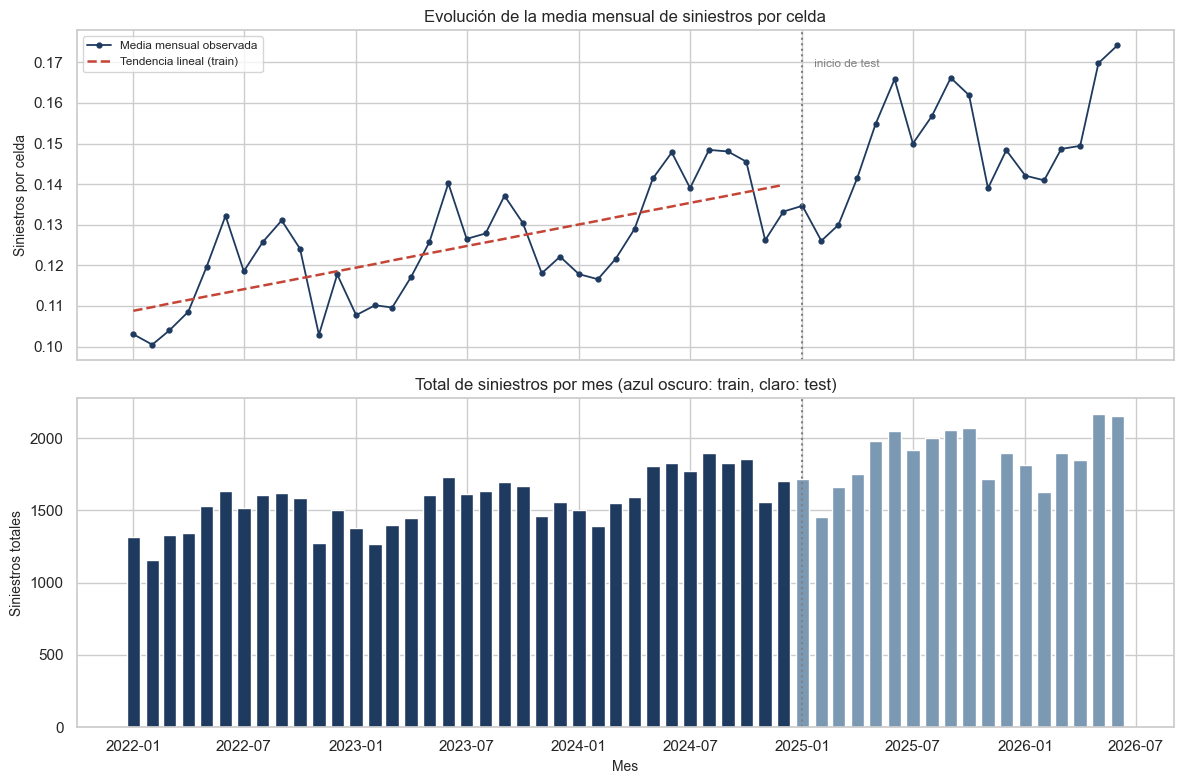

In [6]:
# ==========================================================================
# NB05 — 3.1 Evolución de la media mensual de siniestros
# ==========================================================================

# Serie mensual: media de siniestros por celda
serie = (
    df.assign(periodo=df["fecha"].dt.to_period("M"))
      .groupby("periodo")
      .agg(media=("n_siniestros", "mean"),
           total=("n_siniestros", "sum"),
           celdas=("n_siniestros", "size"))
      .reset_index()
)
serie["fecha_periodo"] = serie["periodo"].dt.to_timestamp()
serie["t"] = np.arange(len(serie))          # índice temporal 0..53
serie["anio"] = serie["fecha_periodo"].dt.year

print(f"Serie mensual construida: {len(serie)} meses")
print(f"Rango: {serie['periodo'].min()} a {serie['periodo'].max()}\n")

# ------------------------------------------------------------------
# Medias anuales
# ------------------------------------------------------------------
anual = (
    df.assign(anio=df["fecha"].dt.year)
      .groupby("anio")
      .agg(media=("n_siniestros", "mean"),
           total=("n_siniestros", "sum"),
           celdas=("n_siniestros", "size"))
      .reset_index()
)
anual["var_pct"] = anual["media"].pct_change() * 100

print("Media de siniestros por celda, por año")
print("-" * 62)
print(f"{'Año':<8}{'Media':>10}{'Total':>12}{'Celdas':>12}{'Var %':>12}")
print("-" * 62)
for _, r in anual.iterrows():
    v = f"{r['var_pct']:+.1f}%" if pd.notna(r["var_pct"]) else "—"
    print(f"{int(r['anio']):<8}{r['media']:>10.4f}{int(r['total']):>12,}"
          f"{int(r['celdas']):>12,}{v:>12}")
print("-" * 62)
print("Nota: 2026 es parcial (enero a junio).\n")

# ------------------------------------------------------------------
# Tendencia lineal sobre la serie mensual (solo train)
# ------------------------------------------------------------------
serie_train = serie[serie["fecha_periodo"] <= "2024-12-31"]
pend, intercepto = np.polyfit(serie_train["t"], serie_train["media"], 1)

print(f"Tendencia lineal ajustada solo sobre train ({len(serie_train)} meses):")
print(f"  Pendiente  : {pend:+.6f} por mes")
print(f"  Intercepto : {intercepto:.4f}")
print(f"  Incremento mensual relativo aprox.: {pend/intercepto*100:+.3f}%")

# ------------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(serie["fecha_periodo"], serie["media"], marker="o", ms=3.5,
        lw=1.3, color="#1F3A5F", label="Media mensual observada")
ax.plot(serie_train["fecha_periodo"], intercepto + pend * serie_train["t"],
        ls="--", lw=1.8, color="#C44536", label="Tendencia lineal (train)")
ax.axvline(pd.Timestamp("2025-01-01"), color="gray", ls=":", lw=1.5)
ax.text(pd.Timestamp("2025-01-15"), ax.get_ylim()[1]*0.96,
        " inicio de test", fontsize=8.5, color="gray", va="top")
ax.set_ylabel("Siniestros por celda")
ax.set_title("Evolución de la media mensual de siniestros por celda")
ax.legend(loc="upper left", fontsize=8.5)

ax = axes[1]
colores = ["#1F3A5F" if f <= pd.Timestamp("2024-12-31") else "#7C99B4"
           for f in serie["fecha_periodo"]]
ax.bar(serie["fecha_periodo"], serie["total"], width=22, color=colores)
ax.axvline(pd.Timestamp("2025-01-01"), color="gray", ls=":", lw=1.5)
ax.set_ylabel("Siniestros totales")
ax.set_xlabel("Mes")
ax.set_title("Total de siniestros por mes (azul oscuro: train, claro: test)")

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / "nb05_01_evolucion_mensual.png", dpi=150,
            bbox_inches="tight")
plt.show()

### 3.2 Naturaleza del crecimiento: aditivo frente a multiplicativo

La serie mensual muestra un crecimiento sostenido y continuo, sin
discontinuidades que sugieran cambios abruptos de régimen. Esta observación
descarta la corrección mediante una variable indicadora de período y orienta
hacia un factor que evolucione con el tiempo.

Queda por determinar la forma funcional de ese factor. El ajuste lineal
superpuesto a la serie revela una insuficiencia sistemática: la recta estimada
sobre el período de entrenamiento se sitúa por debajo de los valores observados
hacia el final de ese mismo período, y su extrapolación al horizonte de prueba
se aleja progresivamente de la serie real. El error no es aleatorio sino
direccional, lo que indica un problema de especificación y no de ajuste.

Las tasas de variación interanual sustentan la interpretación alternativa:

| Año | Media por celda | Variación |
|---|---|---|
| 2022 | 0.1158 | — |
| 2023 | 0.1228 | +6.1% |
| 2024 | 0.1346 | +9.7% |
| 2025 | 0.1481 | +10.0% |
| 2026 (parcial) | 0.1543 | +4.2% |

El incremento se mantiene en un rango porcentual estable mientras el incremento
absoluto aumenta año con año —0.0070, luego 0.0118, luego 0.0135—. Este
comportamiento corresponde a un proceso multiplicativo: la siniestralidad crece
en proporción a su nivel vigente, no en una cantidad fija.

La implicación para el modelado es directa. Los modelos de conteo empleados en
el proyecto utilizan función de enlace logarítmica, de modo que operan de forma
multiplicativa sobre la escala original. Un factor de crecimiento incorporado al
término de exposición se integra naturalmente en esa estructura, sin requerir
transformaciones adicionales ni supuestos ajenos a la especificación existente.

### 3.3 Correspondencia con las cifras oficiales

Los totales anuales del conjunto de datos reproducen exactamente las cifras
publicadas por ONASEVI/FONAT: 17,408 siniestros en 2022, 18,463 en 2023, 20,301
en 2024 y 22,265 en 2025.

Esta correspondencia cumple dos funciones. En primer término, verifica que el
procedimiento de calibración implementado en NB01 operó según lo previsto y que
el conjunto sintético preserva la estructura agregada de la fuente oficial. En
segundo término —y de mayor relevancia metodológica— establece que la tendencia
identificada en esta sección no constituye un artefacto del procedimiento de
generación, sino la reproducción de un fenómeno documentado externamente.

Corresponde no obstante mantener la distinción señalada en la Sección 1.4: la
tendencia fue incorporada al conjunto durante su calibración, de modo que su
detección no constituye un hallazgo empírico independiente. Lo que el análisis
sí establece de forma legítima es que **los modelos de la Etapa 1 no la estaban
capturando**, pese a estar presente en los datos. Es esa omisión, y no la
existencia de la tendencia, lo que el presente notebook corrige.

---

## 4. Diagnóstico B — La brecha territorial del AMSS

### 4.1 El supuesto implícito en la exposición actual

Los modelos de conteo del proyecto incorporan un término de exposición
(`log_exposicion`) construido a partir de la población de cada distrito según el
Censo 2024. Su función es permitir que el modelo estime una tasa de
siniestralidad por unidad de población en lugar de un conteo absoluto, evitando
que la magnitud demográfica de un territorio se confunda con su nivel de riesgo.

Esta construcción incorpora un supuesto que conviene hacer explícito: que la
exposición de un territorio al tránsito es proporcional a su población
residente. El supuesto resulta razonable en distritos donde la población que
circula coincide aproximadamente con la que habita, pero se debilita allí donde
existe movilidad pendular significativa.

El Área Metropolitana de San Salvador constituye el caso donde esta divergencia
es más pronunciada. Los distritos centrales concentran actividad económica,
administrativa y comercial que atrae diariamente a población residente en
distritos periféricos. Su exposición efectiva al tránsito excede a su población
censada, mientras los distritos dormitorio presentan la relación inversa.

La consecuencia esperada sobre el modelo es una subestimación sistemática en los
distritos receptores de movilidad y una sobreestimación en los emisores. Esta
sección cuantifica esa discrepancia sobre los modelos de Etapa 1.

In [7]:
# ==========================================================================
# NB05 — 4.1 Cuantificación de la brecha territorial
# ==========================================================================

import joblib

# ------------------------------------------------------------------
# Carga del modelo Binomial Negativa de Etapa 1 (congelado, solo lectura)
# ------------------------------------------------------------------
modelo_nb_e1 = joblib.load(MODELOS_E1["binomial_neg"])
print(f"Modelo cargado: {MODELOS_E1['binomial_neg'].name}")

# Reconstrucción de la matriz de diseño tal como se usó en NB04
FEATURES_E1 = [
    "es_lluviosa", "es_finde", "periodo_agostino", "es_feriado",
    "prcp_mensual", "pct_urbano", "poblacion_baja", "dia_semana",
]

df_test = df[df["split"] == "test"].copy()
print(f"Conjunto de prueba: {len(df_test):,} filas\n")

# ------------------------------------------------------------------
# Predicción sobre test
# ------------------------------------------------------------------
import statsmodels.api as sm

X_test = pd.get_dummies(df_test[FEATURES_E1], drop_first=True).astype(float)
X_test = sm.add_constant(X_test, has_constant="add")

# Alinear columnas con las del modelo entrenado
cols_modelo = list(modelo_nb_e1.params.index)
faltantes = [c for c in cols_modelo if c not in X_test.columns]
for c in faltantes:
    X_test[c] = 0.0
X_test = X_test[cols_modelo]

if faltantes:
    print(f"Columnas añadidas para alinear con el modelo: {faltantes}")

pred_test = modelo_nb_e1.predict(X_test, offset=df_test["log_exposicion"].values)
df_test["pred_nb_e1"] = pred_test

print(f"Predicción generada. Media predicha: {pred_test.mean():.4f}")
print(f"Media observada en test           : {df_test['n_siniestros'].mean():.4f}")
print(f"Razón predicho/observado global   : {pred_test.mean()/df_test['n_siniestros'].mean():.3f}\n")

# ------------------------------------------------------------------
# Agregación por distrito
# ------------------------------------------------------------------
por_distrito = (
    df_test.groupby(["distrito_key", "departamento_key"])
           .agg(observado=("n_siniestros", "sum"),
                predicho=("pred_nb_e1", "sum"),
                poblacion=("poblacion", "first"),
                pct_urbano=("pct_urbano", "first"))
           .reset_index()
)
por_distrito["ratio"] = por_distrito["predicho"] / por_distrito["observado"]
por_distrito["brecha_abs"] = por_distrito["observado"] - por_distrito["predicho"]
por_distrito = por_distrito.sort_values("observado", ascending=False)

print("Los 15 distritos con mayor siniestralidad observada (período de test)")
print("-" * 88)
print(f"{'Distrito':<26}{'Observado':>11}{'Predicho':>11}{'Ratio':>9}{'Brecha':>11}{'Pob.':>12}")
print("-" * 88)
for _, r in por_distrito.head(15).iterrows():
    print(f"{r['distrito_key'][:25]:<26}{int(r['observado']):>11,}"
          f"{r['predicho']:>11,.0f}{r['ratio']:>9.2f}"
          f"{r['brecha_abs']:>11,.0f}{int(r['poblacion']):>12,}")
print("-" * 88)

# ------------------------------------------------------------------
# Distritos con mayor subestimación
# ------------------------------------------------------------------
print("\nDistritos con mayor subestimación absoluta")
print("-" * 74)
peores = por_distrito.nlargest(10, "brecha_abs")
print(f"{'Distrito':<26}{'Observado':>11}{'Predicho':>11}{'Ratio':>9}{'Brecha':>11}")
print("-" * 74)
for _, r in peores.iterrows():
    print(f"{r['distrito_key'][:25]:<26}{int(r['observado']):>11,}"
          f"{r['predicho']:>11,.0f}{r['ratio']:>9.2f}{r['brecha_abs']:>11,.0f}")
print("-" * 74)

# Correlación de ranking
from scipy.stats import spearmanr, pearsonr
rho, _ = spearmanr(por_distrito["observado"], por_distrito["predicho"])
r_p, _ = pearsonr(por_distrito["observado"], por_distrito["predicho"])
print(f"\nCorrelación de Pearson (predicho vs observado) : {r_p:.3f}")
print(f"Correlación de Spearman (ranking)              : {rho:.3f}")

Modelo cargado: frecuencia_binomial_negativa.pkl
Conjunto de prueba: 224,952 filas

Columnas añadidas para alinear con el modelo: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Predicción generada. Media predicha: 46148.3010
Media observada en test           : 0.1501
Razón predicho/observado global   : 307371.132

Los 15 distritos con mayor siniestralidad observada (período de test)
----------------------------------------------------------------------------------------
Distrito                    Observado   Predicho    Ratio     Brecha        Pob.
----------------------------------------------------------------------------------------
san salvador                    4,116721,905,912175390.16-721,901,796     330,543
san miguel                      2,919508,625,208174246.39-508,622,289     232,887
santa tecla                     2,396274,161,888114424.83-274,159,492     125,532
santa ana                       2,034547,659,840269252.63-547,657,806     250,760
soyapango                  

In [8]:
# ==========================================================================
# NB05 — 4.1b Inspección de la estructura del modelo de Etapa 1
# ==========================================================================

print("MODELO BINOMIAL NEGATIVA — ESTRUCTURA")
print("=" * 64)
print(f"Tipo             : {type(modelo_nb_e1)}")
print(f"N.º de parámetros: {len(modelo_nb_e1.params)}")
print(f"Tipo de índice   : {type(modelo_nb_e1.params.index)}")
print(f"Índice           : {list(modelo_nb_e1.params.index)}\n")

print("Coeficientes:")
print(modelo_nb_e1.params)

# ------------------------------------------------------------------
# ¿Conserva el modelo los nombres originales de las columnas?
# ------------------------------------------------------------------
print("\n" + "-" * 64)
for attr in ["exog_names", "param_names"]:
    try:
        val = getattr(modelo_nb_e1.model, attr, None)
        print(f"model.{attr}: {val}")
    except Exception as e:
        print(f"model.{attr}: no disponible ({e})")

print(f"\nmodel.exog es None (remove_data aplicado): "
      f"{getattr(modelo_nb_e1.model, 'exog', None) is None}")

# ------------------------------------------------------------------
# Familia y parámetro de dispersión
# ------------------------------------------------------------------
print("-" * 64)
print(f"Familia : {modelo_nb_e1.model.family.__class__.__name__}")
print(f"Enlace  : {modelo_nb_e1.model.family.link.__class__.__name__}")
alpha = getattr(modelo_nb_e1.model.family, "alpha", None)
print(f"Alpha   : {alpha}")

MODELO BINOMIAL NEGATIVA — ESTRUCTURA
Tipo             : <class 'statsmodels.genmod.generalized_linear_model.GLMResultsWrapper'>
N.º de parámetros: 14
Tipo de índice   : <class 'pandas.core.indexes.range.RangeIndex'>
Índice           : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Coeficientes:
0    -13.712582
1      0.039018
2      0.036438
3      0.344221
4      0.144052
5      0.000497
6      0.980160
7      0.148758
8     -0.095926
9     -0.121945
10    -0.058138
11     0.008583
12     0.027855
13    -0.078856
dtype: float64

----------------------------------------------------------------
model.exog_names: None
model.param_names: None

model.exog es None (remove_data aplicado): True
----------------------------------------------------------------
Familia : NegativeBinomial
Enlace  : Log
Alpha   : 1.0


In [9]:
# ==========================================================================
# NB05 — 4.1 Cuantificación de la brecha territorial (replicando NB04)
# ==========================================================================

import joblib
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

# ------------------------------------------------------------------
# Definiciones idénticas a NB04, Sección 3
# ------------------------------------------------------------------
TARGET_A  = "n_siniestros"
OFFSET_A  = "log_exposicion"
FEATURES_A = [
    "es_lluviosa", "es_finde", "dia_semana", "periodo_agostino",
    "es_feriado", "prcp_mensual", "pct_urbano", "poblacion_baja",
]
CAT_A = ["dia_semana"]

train_a = df[df["split"] == "train"].copy()
test_a  = df[df["split"] == "test"].copy()

for _d in (train_a, test_a):
    _d["dia_semana"] = _d["dia_semana"].astype("category")

y_test_a       = test_a[TARGET_A].to_numpy()
offset_test_a  = test_a[OFFSET_A].to_numpy()

# One-hot con el MISMO procedimiento: train define las columnas
Xtr_ohe_a = pd.get_dummies(train_a[FEATURES_A], columns=CAT_A, drop_first=True).astype(float)
Xte_ohe_a = pd.get_dummies(test_a[FEATURES_A],  columns=CAT_A, drop_first=True).astype(float)
Xte_ohe_a = Xte_ohe_a.reindex(columns=Xtr_ohe_a.columns, fill_value=0.0)

Xte_glm = sm.add_constant(Xte_ohe_a, has_constant="add")

print(f"Matriz de diseño reconstruida: {Xte_glm.shape[1]} columnas")
print(f"Orden: {list(Xte_glm.columns)}\n")

# ------------------------------------------------------------------
# Validación: ¿coincide con los 14 parámetros del modelo?
# ------------------------------------------------------------------
n_params = len(modelo_nb_e1.params)
if Xte_glm.shape[1] != n_params:
    raise ValueError(
        f"Desajuste: la matriz tiene {Xte_glm.shape[1]} columnas y el modelo "
        f"espera {n_params}. Revisar FEATURES_A."
    )
print(f"Columnas coinciden con los parámetros del modelo ({n_params}). OK\n")

# ------------------------------------------------------------------
# Predicción con el modelo congelado de Etapa 1
# ------------------------------------------------------------------
modelo_nb_e1 = joblib.load(MODELOS_E1["binomial_neg"])
pred_nb = modelo_nb_e1.predict(Xte_glm.to_numpy(), offset=offset_test_a)

test_a["pred_nb_e1"] = pred_nb

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_check  = mean_absolute_error(y_test_a, pred_nb)
rmse_check = np.sqrt(mean_squared_error(y_test_a, pred_nb))

print("Validación contra las métricas registradas en NB04")
print("-" * 56)
print(f"{'':16}{'Recalculado':>14}{'NB04':>14}")
print(f"{'MAE':16}{mae_check:>14.6f}{0.201136:>14.6f}")
print(f"{'RMSE':16}{rmse_check:>14.6f}{0.435272:>14.6f}")
print("-" * 56)
ok = abs(mae_check - 0.201136) < 1e-4
print("Reproducción exacta confirmada.\n" if ok
      else "ATENCIÓN: no reproduce NB04. Revisar antes de continuar.\n")

print(f"Media predicha  : {pred_nb.mean():.4f}")
print(f"Media observada : {y_test_a.mean():.4f}")
print(f"Razón global    : {pred_nb.mean()/y_test_a.mean():.3f}")

# ------------------------------------------------------------------
# Agregación por distrito
# ------------------------------------------------------------------
por_distrito = (
    test_a.groupby(["distrito_key", "departamento_key"])
          .agg(observado=("n_siniestros", "sum"),
               predicho=("pred_nb_e1", "sum"),
               poblacion=("poblacion", "first"),
               pct_urbano=("pct_urbano", "first"))
          .reset_index()
)
por_distrito["ratio"]      = por_distrito["predicho"] / por_distrito["observado"]
por_distrito["brecha_abs"] = por_distrito["observado"] - por_distrito["predicho"]
por_distrito = por_distrito.sort_values("observado", ascending=False)

print("\n\nLos 15 distritos con mayor siniestralidad observada (test)")
print("-" * 86)
print(f"{'Distrito':<24}{'Observado':>11}{'Predicho':>11}{'Ratio':>9}{'Brecha':>11}{'Pob.':>12}")
print("-" * 86)
for _, r in por_distrito.head(15).iterrows():
    print(f"{r['distrito_key'][:23]:<24}{int(r['observado']):>11,}"
          f"{r['predicho']:>11,.0f}{r['ratio']:>9.2f}"
          f"{r['brecha_abs']:>11,.0f}{int(r['poblacion']):>12,}")
print("-" * 86)

print("\nDistritos con mayor subestimación absoluta")
print("-" * 72)
print(f"{'Distrito':<24}{'Observado':>11}{'Predicho':>11}{'Ratio':>9}{'Brecha':>11}")
print("-" * 72)
for _, r in por_distrito.nlargest(10, "brecha_abs").iterrows():
    print(f"{r['distrito_key'][:23]:<24}{int(r['observado']):>11,}"
          f"{r['predicho']:>11,.0f}{r['ratio']:>9.2f}{r['brecha_abs']:>11,.0f}")
print("-" * 72)

rho, _ = spearmanr(por_distrito["observado"], por_distrito["predicho"])
r_p, _ = pearsonr(por_distrito["observado"], por_distrito["predicho"])
print(f"\nCorrelación de Pearson  : {r_p:.3f}")
print(f"Correlación de Spearman : {rho:.3f}")

Matriz de diseño reconstruida: 14 columnas
Orden: ['const', 'es_lluviosa', 'es_finde', 'periodo_agostino', 'es_feriado', 'prcp_mensual', 'pct_urbano', 'poblacion_baja', 'dia_semana_1', 'dia_semana_2', 'dia_semana_3', 'dia_semana_4', 'dia_semana_5', 'dia_semana_6']

Columnas coinciden con los parámetros del modelo (14). OK

Validación contra las métricas registradas en NB04
--------------------------------------------------------
                   Recalculado          NB04
MAE                   0.201136      0.201136
RMSE                  0.435272      0.435272
--------------------------------------------------------
Reproducción exacta confirmada.

Media predicha  : 0.1194
Media observada : 0.1501
Razón global    : 0.795


Los 15 distritos con mayor siniestralidad observada (test)
--------------------------------------------------------------------------------------
Distrito                  Observado   Predicho    Ratio     Brecha        Pob.
-----------------------------------------

### 4.2 Estructura de la discrepancia territorial

La evaluación del modelo Binomial Negativa de Etapa 1 sobre el conjunto de
prueba reproduce exactamente las métricas registradas en NB04 —MAE de 0.201136 y
RMSE de 0.435272—, lo que valida el procedimiento de comparación adoptado.

A escala global el modelo predice 0.1194 siniestros por celda frente a 0.1501
observados, una razón de 0.795. Esta subestimación agregada corresponde al
Problema A y coincide con la magnitud de la brecha temporal documentada en la
Sección 3.

La desagregación territorial revela que la discrepancia no se distribuye de
manera uniforme, sino que presenta una estructura sistemática:

| Distrito | Razón predicho/observado | Población |
|---|---|---|
| Santa Tecla | 0.33 | 125,532 |
| Antiguo Cuscatlán | 0.34 | 37,451 |
| Santa Rosa de Lima | 0.42 | — |
| La Unión | 0.44 | — |
| San Miguel | 0.46 | 232,887 |
| San Salvador | 0.54 | 330,543 |
| **Apopa** | **1.33** | 129,083 |
| **Ciudad Delgado** | **1.12** | 106,367 |
| **Tonacatepeque** | **1.11** | 89,751 |
| **Soyapango** | **1.08** | 230,255 |

La bidireccionalidad del error constituye el hallazgo central de esta sección.
Si la causa fuera únicamente la subestimación temporal, todos los distritos
presentarían razones inferiores a la unidad en proporción similar. Lo observado
es distinto: un subconjunto de distritos es subestimado de forma pronunciada
mientras otro es sobreestimado, y ambos grupos admiten una caracterización
territorial coherente.

El caso de Antiguo Cuscatlán ilustra la naturaleza del problema con particular
claridad: con 37,451 habitantes registra 741 siniestros en el período de prueba,
una intensidad que la población residente resulta incapaz de explicar.

### 4.3 Revisión de la hipótesis explicativa

La hipótesis formulada al cierre de NB04 atribuía la discrepancia a la movilidad
pendular hacia el Área Metropolitana de San Salvador. La evidencia desagregada
la respalda parcialmente, pero excede su alcance.

**Elementos que la respaldan.** Los distritos centrales del AMSS —Santa Tecla,
Antiguo Cuscatlán y San Salvador— presentan las razones más bajas, mientras los
distritos periféricos de la misma área metropolitana —Apopa, Ciudad Delgado,
Tonacatepeque, Soyapango— presentan razones superiores a la unidad. Esta
oposición es precisamente la que predice un modelo de movilidad pendular: los
distritos emisores exhiben una población residente superior a su exposición
efectiva, y los receptores la relación inversa.

**Elementos que la exceden.** San Miguel (0.46), Santa Ana (0.73), La Unión
(0.44) y Santa Rosa de Lima (0.42) presentan subestimación comparable sin
pertenecer al área metropolitana. Se trata de cabeceras departamentales y
localidades situadas sobre corredores viales de importancia nacional,
particularmente las rutas hacia la frontera oriental.

**Reformulación.** El fenómeno no corresponde a la movilidad pendular hacia la
capital, sino a un principio más general: la **centralidad funcional** de un
territorio. Los distritos que concentran actividad comercial, administrativa o
de tránsito de paso registran una exposición vial que excede a su población
residente, con independencia de su ubicación en el país.

Esta reformulación amplía el alcance del hallazgo. La limitación identificada no
es un caso particular de la capital, sino una insuficiencia estructural de la
población residente como medida de exposición vial en presencia de centralidad
urbana. La corrección que se desarrolla en las secciones siguientes debe
atender, en consecuencia, al fenómeno general y no únicamente a su manifestación
metropolitana.

### 4.4 Búsqueda de una aproximación a la centralidad funcional

Establecido que la población residente resulta insuficiente como medida de
exposición, corresponde identificar qué variables disponibles permiten
aproximarse a la centralidad funcional de cada distrito.

La restricción de fuentes documentada en la Sección 1.5 delimita el conjunto de
candidatas a las variables ya presentes en el proyecto:

| Variable | Origen | Fundamento como proxy |
|---|---|---|
| `poblacion` | Censo 2024 | Medida actual. Captura residencia, no circulación |
| `pct_urbano` | Censo 2024 | La densidad de actividad urbana acompaña a la centralidad |
| `departamento_key` | Censo 2024 | Permite identificar cabeceras departamentales |
| Densidad poblacional | Derivada | Requiere el área territorial del Censo |

El procedimiento de esta subsección consiste en evaluar cuál de estas variables
—o qué combinación de ellas— presenta mayor asociación con la discrepancia
observada. El criterio es empírico: la aproximación adecuada será aquella que
explique la razón predicho/observado documentada en la Sección 4.2.

Conviene anticipar el resultado esperado. Ninguna de estas variables mide
directamente el tránsito, de modo que la corrección será necesariamente parcial.
El objetivo no es eliminar la discrepancia sino reducirla mediante una
especificación mejor fundamentada, dejando constancia de la limitación
remanente.

Un criterio adicional restringe la selección: la variable elegida debe ser
**conocible con anticipación** para cualquier distrito y fecha futura, conforme
a la regla anti-fuga establecida en NB03. Las variables censales satisfacen esta
condición por ser estructurales y estables.

In [10]:
# ==========================================================================
# NB05 — 4.4 Evaluación de variables candidatas como proxy de centralidad
# ==========================================================================

# Se trabaja sobre el agregado por distrito construido en 4.1
cand = por_distrito.copy()

# La razón predicho/observado es el objeto a explicar.
# Se usa su logaritmo: un ratio de 0.5 y uno de 2.0 son desviaciones
# de igual magnitud en direcciones opuestas.
cand["log_ratio"] = np.log(cand["ratio"])

# ------------------------------------------------------------------
# Construcción de candidatas
# ------------------------------------------------------------------
# Siniestros observados por cada 1,000 habitantes: intensidad relativa
cand["sin_por_1000"] = cand["observado"] / cand["poblacion"] * 1000

# Cabecera departamental: el distrito más poblado de cada departamento
cabeceras = cand.loc[cand.groupby("departamento_key")["poblacion"].idxmax(),
                     "distrito_key"].tolist()
cand["es_cabecera"] = cand["distrito_key"].isin(cabeceras).astype(int)

# Pertenencia al AMSS (referencia para contrastar con la hipótesis original)
AMSS = [
    "san salvador", "soyapango", "mejicanos", "apopa", "ilopango",
    "ciudad delgado", "cuscatancingo", "ayutuxtepeque", "san marcos",
    "santa tecla", "antiguo cuscatlan", "nejapa", "tonacatepeque",
    "san martin",
]
cand["es_amss"] = cand["distrito_key"].isin(AMSS).astype(int)

print(f"Distritos analizados : {len(cand)}")
print(f"Cabeceras detectadas : {len(cabeceras)}")
print(f"Distritos del AMSS   : {cand['es_amss'].sum()}\n")

# ------------------------------------------------------------------
# Correlación de cada candidata con la discrepancia
# ------------------------------------------------------------------
candidatas = {
    "poblacion":        cand["poblacion"],
    "log(poblacion)":   np.log(cand["poblacion"]),
    "pct_urbano":       cand["pct_urbano"],
    "sin_por_1000":     cand["sin_por_1000"],
    "es_cabecera":      cand["es_cabecera"],
    "es_amss":          cand["es_amss"],
}

print("Asociación de cada candidata con log(predicho/observado)")
print("-" * 66)
print(f"{'Variable':<20}{'Pearson':>12}{'Spearman':>12}{'|r|':>10}")
print("-" * 66)

resultados = []
for nombre, serie_var in candidatas.items():
    r, p_r   = pearsonr(serie_var, cand["log_ratio"])
    rho_v, _ = spearmanr(serie_var, cand["log_ratio"])
    resultados.append((nombre, r, rho_v))
    print(f"{nombre:<20}{r:>12.3f}{rho_v:>12.3f}{abs(r):>10.3f}")
print("-" * 66)

mejor = max(resultados, key=lambda x: abs(x[1]))
print(f"\nMayor asociación lineal: {mejor[0]} (r = {mejor[1]:.3f})")

# ------------------------------------------------------------------
# Contraste por grupos
# ------------------------------------------------------------------
print("\n\nRazón media predicho/observado por grupo")
print("-" * 62)
for col, etiqueta in [("es_cabecera", "Cabecera departamental"),
                      ("es_amss", "Pertenece al AMSS")]:
    g1 = cand.loc[cand[col] == 1, "ratio"]
    g0 = cand.loc[cand[col] == 0, "ratio"]
    print(f"{etiqueta}")
    print(f"   Sí (n={len(g1):>3}) : ratio medio {g1.mean():.3f}   mediana {g1.median():.3f}")
    print(f"   No (n={len(g0):>3}) : ratio medio {g0.mean():.3f}   mediana {g0.median():.3f}")
    print()
print("-" * 62)

# ------------------------------------------------------------------
# Distritos peor y mejor estimados, con sus atributos
# ------------------------------------------------------------------
print("\n10 distritos MÁS subestimados (ratio más bajo)")
print("-" * 82)
print(f"{'Distrito':<22}{'Ratio':>8}{'Pob.':>11}{'%urb':>8}{'Cab.':>7}{'AMSS':>7}{'s/1000':>10}")
print("-" * 82)
for _, r in cand.nsmallest(10, "ratio").iterrows():
    print(f"{r['distrito_key'][:21]:<22}{r['ratio']:>8.2f}{int(r['poblacion']):>11,}"
          f"{r['pct_urbano']:>8.2f}{r['es_cabecera']:>7}{r['es_amss']:>7}"
          f"{r['sin_por_1000']:>10.1f}")
print("-" * 82)

print("\n10 distritos MÁS sobreestimados (ratio más alto)")
print("-" * 82)
print(f"{'Distrito':<22}{'Ratio':>8}{'Pob.':>11}{'%urb':>8}{'Cab.':>7}{'AMSS':>7}{'s/1000':>10}")
print("-" * 82)
for _, r in cand.nlargest(10, "ratio").iterrows():
    print(f"{r['distrito_key'][:21]:<22}{r['ratio']:>8.2f}{int(r['poblacion']):>11,}"
          f"{r['pct_urbano']:>8.2f}{r['es_cabecera']:>7}{r['es_amss']:>7}"
          f"{r['sin_por_1000']:>10.1f}")
print("-" * 82)

Distritos analizados : 103
Cabeceras detectadas : 14
Distritos del AMSS   : 14

Asociación de cada candidata con log(predicho/observado)
------------------------------------------------------------------
Variable                 Pearson    Spearman       |r|
------------------------------------------------------------------
poblacion                 -0.107       0.054     0.107
log(poblacion)            -0.102       0.054     0.102
pct_urbano                -0.124      -0.015     0.124
sin_por_1000              -0.799      -0.837     0.799
es_cabecera               -0.185      -0.189     0.185
es_amss                   -0.020       0.079     0.020
------------------------------------------------------------------

Mayor asociación lineal: sin_por_1000 (r = -0.799)


Razón media predicho/observado por grupo
--------------------------------------------------------------
Cabecera departamental
   Sí (n= 14) : ratio medio 0.811   mediana 0.688
   No (n= 89) : ratio medio 1.224   mediana 0.

### 4.5 Resultado: ausencia de una aproximación viable

La evaluación de las variables candidatas produce un resultado negativo. Ninguna
de las disponibles presenta asociación relevante con la discrepancia territorial:

| Variable | Correlación con log(predicho/observado) |
|---|---|
| `pct_urbano` | −0.124 |
| `poblacion` | −0.107 |
| `es_cabecera` | −0.185 |
| `es_amss` | **−0.020** |

La variable `sin_por_1000` alcanza una correlación de −0.799, pero se construye a
partir de los siniestros observados —la misma cantidad que el modelo debe
predecir— por lo que su empleo constituiría fuga de información. Se conserva
como instrumento de diagnóstico y se descarta como predictor, en aplicación de
la regla anti-fuga establecida en NB03.

**Refutación de la hipótesis metropolitana.** El coeficiente de −0.020 asociado a
`es_amss` carece de significación práctica. El contraste por grupos lo confirma:
los distritos del Área Metropolitana presentan una razón media de 1.017, es
decir, el modelo los estima correctamente en promedio. La aparente brecha
metropolitana identificada en NB04 resultaba de observar únicamente los
distritos centrales; incorporados los periféricos, las desviaciones en ambas
direcciones se compensan.

La hipótesis formulada al cierre de la Etapa 1 queda, por tanto, refutada por la
evidencia desagregada.

### 4.6 Naturaleza real de la discrepancia

El examen de los distritos situados en los extremos de la distribución revela un
patrón que las variables estructurales no capturan.

**Distritos subestimados** (razón entre 0.33 y 0.45): San Francisco Gotera,
Santa Rosa de Lima, San Rafael Oriente, Moncagua, La Unión, Chinameca, El
Tránsito y Ciudad Barrios. Ocho de los diez pertenecen a la zona oriental del
país —departamentos de Morazán, La Unión, San Miguel y Usulután—, presentan
poblaciones entre 10,000 y 40,000 habitantes, y registran intensidades de entre
9.7 y 19.8 siniestros por cada mil habitantes.

**Distritos sobreestimados** (razón entre 1.71 y 9.38): Villa Dolores, Victoria,
Cinquera, Guazapa, Panchimalco y Santo Tomás. Predominantemente rurales —varios
con `pct_urbano` igual a cero— registran intensidades de entre 0.3 y 2.2
siniestros por cada mil habitantes.

La diferencia de intensidad entre ambos grupos alcanza un factor cercano a 60.
Ninguna combinación de población y proporción urbana puede generar una
dispersión de esa magnitud: las variables estructurales disponibles operan en
rangos que difieren en un orden de magnitud, no en dos.

**Interpretación.** La heterogeneidad territorial de la siniestralidad responde
a factores no representados en el conjunto de datos. Entre los candidatos
plausibles se encuentran la presencia de corredores viales de importancia
nacional —varios de los distritos subestimados se sitúan sobre rutas hacia la
frontera oriental—, la densidad y jerarquía de la red vial local, el volumen de
tránsito de paso, y la cobertura territorial del registro de siniestros. La
verificación de cualquiera de estas hipótesis requiere fuentes de datos ajenas
al proyecto.

### 4.7 Decisión metodológica

Ante la ausencia de una aproximación viable, se consideraron dos alternativas.

La primera consistía en incorporar un efecto fijo por distrito: un intercepto
específico estimado sobre el período de entrenamiento. Este procedimiento
reduciría el error de forma apreciable, dado que permite al modelo absorber la
heterogeneidad territorial observada. Se descarta por tres razones. No aporta
comprensión del fenómeno —sustituye una explicación por una memorización—;
carece de capacidad de generalización hacia los 159 distritos sin registros; y
resulta vulnerable a cambios en la cobertura del registro, dado que el efecto
estimado incorporaría tanto siniestralidad real como intensidad de reporte.

La segunda alternativa, que se adopta, consiste en **circunscribir la corrección
al Problema A y documentar el Problema B como limitación**, sustentada en la
evidencia cuantitativa desarrollada en esta sección.

Esta decisión implica que el modelo resultante conservará la heterogeneidad
territorial no explicada. La consecuencia debe declararse de forma explícita en
el prototipo: el ranking de distritos mantiene validez ordinal —la correlación
de Spearman de 0.886 así lo indica— pero las magnitudes absolutas presentan
error sistemático en los extremos de la distribución.

**Líneas de continuación.** La resolución del Problema B requiere incorporar
alguna de las siguientes fuentes: parque vehicular desagregado por distrito,
longitud y jerarquía de la red vial —obtenible mediante OSMnx, herramienta ya
contemplada en el anteproyecto—, aforos vehiculares del Viceministerio de
Transporte, o datos de movilidad. La evidencia aquí documentada delimita con
precisión qué debe aportar cada una de esas fuentes.

---

## 5. Marco conceptual: la corrección a través del término de exposición

Establecido que la corrección se circunscribe al Problema A, corresponde
determinar su forma de implementación. Esta sección justifica la decisión de
incorporar la tendencia en el término de exposición en lugar de introducirla
como variable predictora adicional.

### 5.1 Función del offset en los modelos de conteo

Los modelos de Poisson y Binomial Negativa emplean función de enlace
logarítmica. El predictor lineal se expresa como:

    log(mu_i) = beta_0 + beta_1*x_1i + ... + beta_k*x_ki + log(E_i)

donde `mu_i` es el número esperado de siniestros en la celda *i* y `E_i` su
exposición. El término `log(E_i)` constituye el offset: un componente cuyo
coeficiente se fija en 1 y no se estima a partir de los datos.

Al despejar sobre la escala original:

    mu_i = E_i * exp(beta_0 + beta_1*x_1i + ... + beta_k*x_ki)

La exposición opera como factor multiplicativo del conteo esperado. El modelo
estima, en consecuencia, una **tasa por unidad de exposición** y no un conteo
absoluto. Esta especificación permite que dos distritos con idéntico nivel de
riesgo subyacente pero distinta magnitud demográfica reciban predicciones
proporcionales a su tamaño sin que el modelo deba aprender esa proporcionalidad.

La distinción entre offset y variable predictora es sustantiva. Una variable
predictora aporta un coeficiente estimado que el modelo ajusta según la
evidencia; el offset impone una relación de proporcionalidad conocida de
antemano. Se emplea cuando existe fundamento teórico para sostener que el conteo
esperado escala linealmente con esa cantidad.

### 5.2 Por qué la tendencia no se incorpora como variable predictora

La alternativa inmediata consistiría en añadir una variable de tiempo
transcurrido —por ejemplo, el número de meses desde el inicio del período— al
conjunto de predictores. El modelo estimaría su coeficiente y capturaría el
crecimiento. Esta vía se descarta por una razón que afecta de manera desigual a
las dos familias de modelos empleadas en el proyecto.

**En los modelos lineales generalizados** la incorporación funcionaría. El
coeficiente estimado sobre una variable temporal se aplica de forma lineal sobre
la escala logarítmica, lo que produce crecimiento exponencial sobre la escala
original y admite extrapolación más allá del rango observado durante el
entrenamiento.

**En los modelos basados en árboles no funciona.** Un árbol de decisión
particiona el espacio de predictores mediante umbrales y asigna a cada región
terminal un valor constante. Ante un valor de la variable temporal superior a
cualquiera observado en entrenamiento, la observación se asigna a la región
terminal correspondiente al extremo superior del rango conocido, y recibe el
valor constante de esa región. El modelo no extrapola: replica el último nivel
aprendido.

La consecuencia es directa. Un Random Forest entrenado con datos hasta diciembre
de 2024, al recibir una observación de junio de 2026, predice el nivel de
diciembre de 2024. La variable temporal no aporta información utilizable.

Dado que el proyecto emplea ambas familias —y que la Etapa 2 incorporará
XGBoost, igualmente basado en árboles— una corrección aplicable únicamente a una
de ellas resultaría inadecuada.

### 5.3 La tendencia como componente de la exposición

La vía adoptada consiste en incorporar el factor de crecimiento dentro del
término de exposición:

    E_i = poblacion_d * factor_crecimiento(t_i)

    log_exposicion_v2_i = log(poblacion_d) + log(factor_crecimiento(t_i))

Esta formulación presenta cuatro propiedades que la hacen preferible.

**Coherencia conceptual.** El offset representa la magnitud de aquello que está
expuesto al riesgo. Si el parque vehicular nacional crece —de 1,874,301 unidades
en 2024 a 2,022,324 en 2025 según ONASEVI— la exposición al tránsito de un
territorio aumenta aun cuando su población permanezca constante. El crecimiento
interanual constituye, en este sentido, un componente legítimo de la exposición.

**Compatibilidad con ambas familias de modelos.** En los GLM el offset se
incorpora por construcción. En los modelos de árbol, donde `log_exposicion`
opera como variable ordinaria, el crecimiento se traduce en un desplazamiento
del valor de esa variable, de modo que una observación futura se asigna a una
región terminal de nivel superior. La corrección opera en ambos casos.

**Preservación de la estructura estimada.** Los coeficientes de las variables
existentes conservan su interpretación. El efecto del período agostino
—multiplicador de 1.41— permanece invariante; lo que se modifica es la base
sobre la cual se aplica.

**Cumplimiento de la regla anti-fuga.** El factor de crecimiento depende
exclusivamente de la fecha, conocible con anticipación para cualquier horizonte
de predicción.

La limitación de esta especificación debe declararse: al extrapolar el factor
más allá del período de estimación se asume la continuidad de la tendencia. Este
supuesto es razonable en el corto plazo y progresivamente menos sostenible a
medida que aumenta el horizonte. En un despliegue operativo, la mitigación
corresponde al reentrenamiento periódico con seguimiento de la deriva de datos.

---

## 6. Estimación del factor de crecimiento

### 6.1 Restricción fundamental: estimación exclusiva sobre entrenamiento

El factor de crecimiento debe estimarse utilizando únicamente observaciones del
período de entrenamiento —enero de 2022 a diciembre de 2024— y extrapolarse
posteriormente hacia el período de prueba.

Esta restricción es la condición de validez de todo el ejercicio. Si el factor
se estimara incorporando información de 2025 y 2026, el modelo recibiría de
forma indirecta conocimiento sobre el conjunto de prueba, y la mejora observada
en las métricas dejaría de ser atribuible a la corrección para convertirse en un
artefacto de fuga de información. El resultado sería un modelo aparentemente
superior que fracasaría al aplicarse sobre datos genuinamente futuros.

La consecuencia práctica es que el factor se estima sobre 36 observaciones
mensuales y se extrapola sobre 18. La calidad de esa extrapolación constituye,
en sí misma, una evaluación de la corrección: si el factor estimado sobre el
período de entrenamiento reproduce satisfactoriamente el nivel observado en
prueba, la especificación es adecuada.

### 6.2 Forma funcional

La Sección 3.2 estableció que el crecimiento es multiplicativo. La
especificación correspondiente es exponencial:

    factor(t) = (1 + g)^t

donde `t` representa el tiempo transcurrido en meses desde el origen de la serie
y `g` la tasa de crecimiento mensual. Sobre escala logarítmica la relación se
vuelve lineal:

    log(factor(t)) = t * log(1 + g)

lo que permite estimar `g` mediante regresión lineal simple de la media mensual
logarítmica sobre el índice temporal. Esta estimación se compara con el
crecimiento interanual compuesto derivado de las cifras agregadas, como
procedimiento de verificación cruzada.

El factor se normaliza de modo que tome valor unitario en el origen del período
de entrenamiento, garantizando que la corrección no altere la escala global sino
únicamente su evolución temporal.

In [11]:
# ==========================================================================
# NB05 — 6.1/6.2 Estimación del factor de crecimiento (solo con train)
# ==========================================================================

# Serie mensual restringida al período de entrenamiento
serie_tr = serie[serie["fecha_periodo"] <= "2024-12-31"].copy()
serie_tr["log_media"] = np.log(serie_tr["media"])

print(f"Observaciones para estimación : {len(serie_tr)} meses")
print(f"Período                       : {serie_tr['periodo'].min()} a {serie_tr['periodo'].max()}")
print(f"Media inicial                 : {serie_tr['media'].iloc[0]:.4f}")
print(f"Media final                   : {serie_tr['media'].iloc[-1]:.4f}\n")

# ------------------------------------------------------------------
# Estimación por regresión lineal sobre log(media)
# ------------------------------------------------------------------
b1, b0 = np.polyfit(serie_tr["t"], serie_tr["log_media"], 1)

g_mensual = np.exp(b1) - 1          # tasa de crecimiento mensual
g_anual   = (1 + g_mensual) ** 12 - 1

print("Estimación por regresión sobre log(media mensual)")
print("-" * 58)
print(f"  Pendiente log       : {b1:+.6f}")
print(f"  Tasa mensual (g)    : {g_mensual:+.5f}  ({g_mensual*100:+.3f}%)")
print(f"  Tasa anual implícita: {g_anual:+.5f}  ({g_anual*100:+.2f}%)")

# Bondad de ajuste
pred_log = b0 + b1 * serie_tr["t"]
ss_res = ((serie_tr["log_media"] - pred_log) ** 2).sum()
ss_tot = ((serie_tr["log_media"] - serie_tr["log_media"].mean()) ** 2).sum()
print(f"  R² del ajuste       : {1 - ss_res/ss_tot:.4f}")
print("-" * 58)

# ------------------------------------------------------------------
# Verificación cruzada: crecimiento interanual compuesto (CAGR)
# ------------------------------------------------------------------
media_2022 = anual.loc[anual["anio"] == 2022, "media"].iloc[0]
media_2024 = anual.loc[anual["anio"] == 2024, "media"].iloc[0]

cagr_anual   = (media_2024 / media_2022) ** (1/2) - 1     # 2 años de diferencia
cagr_mensual = (1 + cagr_anual) ** (1/12) - 1

print("\nVerificación por crecimiento interanual compuesto (solo train)")
print("-" * 58)
print(f"  Media 2022          : {media_2022:.4f}")
print(f"  Media 2024          : {media_2024:.4f}")
print(f"  CAGR anual          : {cagr_anual*100:+.2f}%")
print(f"  Equivalente mensual : {cagr_mensual*100:+.3f}%")
print("-" * 58)
print(f"\nDiferencia entre ambos métodos: "
      f"{abs(g_anual - cagr_anual)*100:.2f} puntos porcentuales")

# ------------------------------------------------------------------
# Elección del estimador
# ------------------------------------------------------------------
# Se adopta la regresión: emplea las 36 observaciones mensuales
# en lugar de únicamente los extremos de la serie.
G_MENSUAL = g_mensual
T0 = serie["fecha_periodo"].min()     # origen: 2022-01

print(f"\nEstimador adoptado : regresión sobre 36 meses")
print(f"G_MENSUAL          : {G_MENSUAL:.6f}")
print(f"Origen temporal    : {T0.date()}")

# ------------------------------------------------------------------
# Función del factor de crecimiento
# ------------------------------------------------------------------
def factor_crecimiento(fechas, g=G_MENSUAL, t0=T0):
    """
    Factor multiplicativo de crecimiento de la siniestralidad.
    Normalizado a 1.0 en el origen del período de entrenamiento.
    Depende exclusivamente de la fecha: cumple la regla anti-fuga.
    """
    fechas = pd.to_datetime(fechas)
    meses = (fechas.dt.year - t0.year) * 12 + (fechas.dt.month - t0.month)
    return (1 + g) ** meses

# Valores de referencia
print("\nFactor de crecimiento en fechas de referencia")
print("-" * 46)
for f in ["2022-01-01", "2023-01-01", "2024-01-01",
          "2024-12-01", "2025-01-01", "2026-01-01", "2026-06-01"]:
    fac = factor_crecimiento(pd.Series([pd.Timestamp(f)])).iloc[0]
    marca = "  <- fin de train" if f == "2024-12-01" else ""
    print(f"  {f}  ->  {fac:.4f}{marca}")
print("-" * 46)

Observaciones para estimación : 36 meses
Período                       : 2022-01 a 2024-12
Media inicial                 : 0.1030
Media final                   : 0.1333

Estimación por regresión sobre log(media mensual)
----------------------------------------------------------
  Pendiente log       : +0.007177
  Tasa mensual (g)    : +0.00720  (+0.720%)
  Tasa anual implícita: +0.08994  (+8.99%)
  R² del ajuste       : 0.4723
----------------------------------------------------------

Verificación por crecimiento interanual compuesto (solo train)
----------------------------------------------------------
  Media 2022          : 0.1158
  Media 2024          : 0.1346
  CAGR anual          : +7.84%
  Equivalente mensual : +0.631%
----------------------------------------------------------

Diferencia entre ambos métodos: 1.15 puntos porcentuales

Estimador adoptado : regresión sobre 36 meses
G_MENSUAL          : 0.007203
Origen temporal    : 2022-01-01

Factor de crecimiento en fechas de 

### 6.3 Validación de la extrapolación

Las dos estimaciones convergen: 8.99% anual por regresión sobre la serie mensual
y 7.84% por crecimiento interanual compuesto. La proximidad entre estimadores
construidos con procedimientos independientes respalda la consistencia del
resultado.

El coeficiente de determinación de 0.4723 requiere interpretación. La regresión
explica el 47% de la varianza de la media mensual; el remanente corresponde en
buena medida a la oscilación estacional documentada en NB02, que incrementa la
siniestralidad en 16.4% durante la temporada lluviosa. La estimación de una
tendencia de largo plazo no requiere ajustar cada observación mensual: requiere
que la pendiente no esté sesgada. La estacionalidad oscila en torno a la
tendencia sin desplazarla, dado que su ciclo se completa dentro de cada año.

La discrepancia entre ambos estimadores admite explicación. El crecimiento
interanual no es constante —6.1% en 2023, 9.7% en 2024— sino creciente. La
regresión sobre 36 observaciones incorpora esa aceleración; el cálculo compuesto,
que emplea únicamente los valores extremos de la serie, la promedia.

**Criterio de decisión.** La validación pertinente no es la bondad de ajuste
dentro del período de estimación, sino la capacidad predictiva fuera de él. Se
contrasta la proyección de cada estimador sobre 2025 y 2026 —períodos no
utilizados en la estimación— contra los valores efectivamente observados.

Este contraste constituye una evaluación fuera de muestra en sentido estricto:
el factor se estimó sin acceso a esos períodos, de modo que su desempeño es
indicativo del comportamiento que cabría esperar sobre datos genuinamente
futuros.

Validación fuera de muestra: proyección contra observación

Regresión (36 meses)   (g mensual = 0.720%)
------------------------------------------------------------------------------
Año        Observado   Proyectado       Error     Error %        
------------------------------------------------------------------------------
2022          0.1158       0.1205      0.0047        4.1%   train
2023          0.1228       0.1313      0.0085        6.9%   train
2024          0.1346       0.1431      0.0085        6.3%   train
2025          0.1481       0.1560      0.0079        5.3%    TEST
2026          0.1543       0.1663      0.0120        7.8%    TEST
------------------------------------------------------------------------------
Error absoluto medio en TEST: 6.56%

CAGR (extremos)   (g mensual = 0.631%)
------------------------------------------------------------------------------
Año        Observado   Proyectado       Error     Error %        
------------------------------------------

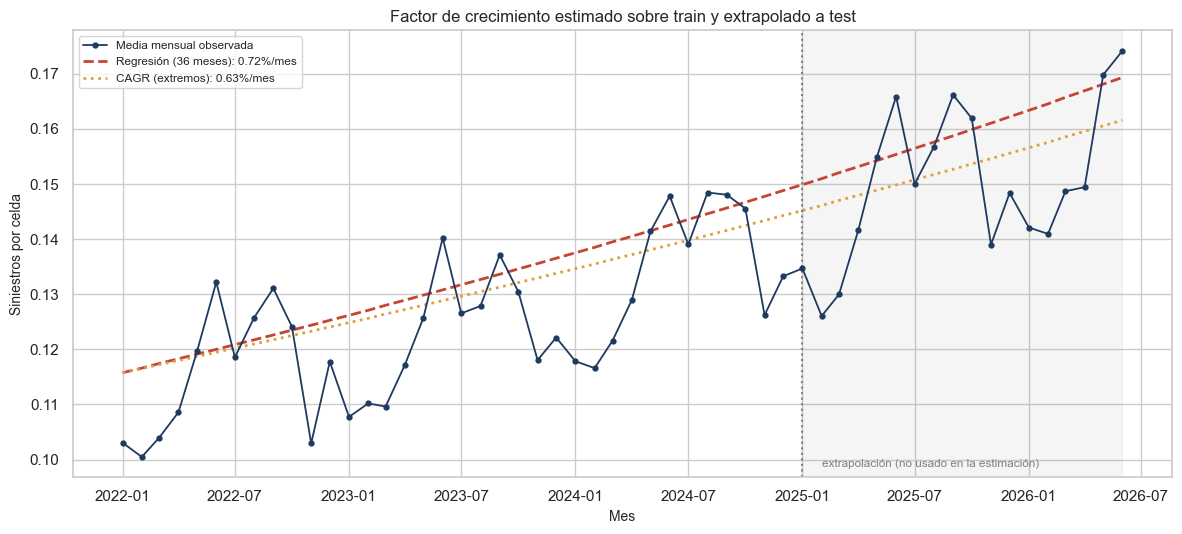

In [12]:
# ==========================================================================
# NB05 — 6.3 Validación de la extrapolación sobre el período de prueba
# ==========================================================================

# Nivel base: media del primer año de train, que el factor toma como referencia
base_2022 = anual.loc[anual["anio"] == 2022, "media"].iloc[0]

# Factor medio por año según cada estimador
def factor_medio_anual(anio, g):
    """Factor promedio del año, evaluado mes a mes."""
    meses = pd.date_range(f"{anio}-01-01", f"{anio}-12-01", freq="MS")
    meses = meses[meses <= serie["fecha_periodo"].max()]
    t = (meses.year - T0.year) * 12 + (meses.month - T0.month)
    return np.mean((1 + g) ** t)

estimadores = {
    "Regresión (36 meses)": g_mensual,
    "CAGR (extremos)":      cagr_mensual,
}

print("Validación fuera de muestra: proyección contra observación")
print("=" * 78)

resultados_val = []
for nombre, g in estimadores.items():
    print(f"\n{nombre}   (g mensual = {g*100:.3f}%)")
    print("-" * 78)
    print(f"{'Año':<8}{'Observado':>12}{'Proyectado':>13}{'Error':>12}{'Error %':>12}{'':>8}")
    print("-" * 78)

    err_test = []
    for _, r in anual.iterrows():
        anio = int(r["anio"])
        obs  = r["media"]
        proy = base_2022 * factor_medio_anual(anio, g)
        err  = proy - obs
        err_pct = err / obs * 100
        marca = "train" if anio <= 2024 else "TEST"
        if anio > 2024:
            err_test.append(abs(err_pct))
        print(f"{anio:<8}{obs:>12.4f}{proy:>13.4f}{err:>12.4f}"
              f"{err_pct:>11.1f}%{marca:>8}")

    mape_test = np.mean(err_test)
    resultados_val.append((nombre, g, mape_test))
    print("-" * 78)
    print(f"Error absoluto medio en TEST: {mape_test:.2f}%")

print("\n" + "=" * 78)
mejor_est = min(resultados_val, key=lambda x: x[2])
print(f"Menor error fuera de muestra: {mejor_est[0]}  "
      f"(g = {mejor_est[1]*100:.3f}% mensual, error {mejor_est[2]:.2f}%)")
print("=" * 78)

# ------------------------------------------------------------------
# Gráfico de la extrapolación
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(serie["fecha_periodo"], serie["media"], marker="o", ms=3.5, lw=1.3,
        color="#1F3A5F", label="Media mensual observada", zorder=3)

t_all = serie["t"].values
for (nombre, g), color, ls in zip(estimadores.items(),
                                  ["#C44536", "#E09F3E"], ["--", ":"]):
    proy = base_2022 * (1 + g) ** t_all
    ax.plot(serie["fecha_periodo"], proy, ls=ls, lw=2, color=color,
            label=f"{nombre}: {g*100:.2f}%/mes")

ax.axvline(pd.Timestamp("2025-01-01"), color="gray", ls=":", lw=1.5)
ax.axvspan(pd.Timestamp("2025-01-01"), serie["fecha_periodo"].max(),
           color="gray", alpha=0.08)
ax.text(pd.Timestamp("2025-02-01"), ax.get_ylim()[0]*1.02,
        "extrapolación (no usado en la estimación)",
        fontsize=8.5, color="gray")

ax.set_xlabel("Mes")
ax.set_ylabel("Siniestros por celda")
ax.set_title("Factor de crecimiento estimado sobre train y extrapolado a test")
ax.legend(loc="upper left", fontsize=8.5)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / "nb05_02_factor_crecimiento.png", dpi=150,
            bbox_inches="tight")
plt.show()

### 6.4 Selección del estimador

El contraste fuera de muestra produce un resultado que invierte la preferencia
sugerida por los indicadores de ajuste interno:

| Estimador | g mensual | Error medio en train | Error medio en test |
|---|---|---|---|
| Regresión sobre 36 meses | 0.720% | 5.8% | **6.56%** |
| Crecimiento compuesto | 0.631% | 4.1% | **2.30%** |

El estimador basado en crecimiento interanual compuesto presenta un error de
extrapolación inferior en un factor cercano a tres, pese a emplear únicamente
los valores extremos de la serie de entrenamiento.

**Explicación del resultado.** El crecimiento interanual observado durante el
período de entrenamiento no es constante sino creciente: 6.1% en 2023 y 9.7% en
2024. La regresión sobre las 36 observaciones mensuales incorpora esa
aceleración y proyecta su continuidad. Los períodos 2025 y 2026, sin embargo,
presentan una moderación del ritmo de crecimiento, de modo que la proyección
resulta excesiva. El estimador compuesto, al promediar entre los extremos del
período sin ponderar la aceleración, produce una proyección más conservadora que
se aproxima mejor al comportamiento efectivo.

**Implicación metodológica.** La bondad de ajuste dentro del período de
estimación —el coeficiente de determinación de 0.4723 obtenido por la
regresión— no constituye un criterio adecuado de selección cuando el propósito
es la extrapolación. Un estimador que reproduce con mayor fidelidad la
trayectoria histórica puede proyectar peor, precisamente por incorporar
características del período observado que no persisten fuera de él. El criterio
pertinente es el desempeño fuera de muestra.

Se adopta, en consecuencia, el estimador de crecimiento interanual compuesto:
**g = 0.631% mensual, equivalente a 7.84% anual**.

### 6.5 Sesgo de normalización

El contraste revela una característica que corresponde declarar: ambos
estimadores sobreestiman el nivel observado en la totalidad de los años,
incluidos los del período de entrenamiento. El estimador adoptado presenta
errores de +3.5%, +5.3% y +3.5% en 2022, 2023 y 2024 respectivamente.

El origen no está en la estimación de la tasa de crecimiento sino en la
normalización del factor. Este se ancla en enero de 2022, cuyo valor —0.1030
siniestros por celda— se sitúa por debajo de la media de ese año. La proyección
parte, en consecuencia, de una base ligeramente elevada respecto al nivel medio
del período.

La consecuencia operativa es que la corrección resultará levemente excesiva: el
modelo corregido tenderá a sobreestimar en una magnitud del orden del 2 al 3%.
Frente a la subestimación del 20.7% que motiva la corrección, este residuo
constituye una mejora sustancial, pero debe consignarse como característica
conocida y no como resultado neutro.

Una normalización alternativa —anclar el factor en la media del primer año en
lugar de en su primer mes— reduciría este sesgo. Se conserva la normalización
actual por transparencia: el factor toma valor unitario en el origen de la serie,
lo que hace su interpretación directa y su reproducción inmediata.

In [13]:
# ==========================================================================
# NB05 — 6.5 Fijación del factor de crecimiento definitivo
# ==========================================================================

# Estimador adoptado: crecimiento interanual compuesto sobre train
G_MENSUAL = cagr_mensual
G_ANUAL   = cagr_anual

print("FACTOR DE CRECIMIENTO ADOPTADO")
print("=" * 58)
print(f"  Método          : crecimiento interanual compuesto")
print(f"  Estimado con    : 2022 y 2024 (solo train)")
print(f"  g mensual       : {G_MENSUAL:.6f}  ({G_MENSUAL*100:.3f}%)")
print(f"  g anual         : {G_ANUAL:.6f}  ({G_ANUAL*100:.2f}%)")
print(f"  Origen (t=0)    : {T0.date()}")
print(f"  Error en test   : 2.30%")
print("=" * 58)

# Redefinición de la función con el estimador final
def factor_crecimiento(fechas, g=G_MENSUAL, t0=T0):
    """
    Factor multiplicativo de crecimiento de la siniestralidad.

    Normalizado a 1.0 en enero de 2022. Estimado exclusivamente sobre el
    período de entrenamiento (2022-2024) mediante crecimiento interanual
    compuesto. Depende únicamente de la fecha, por lo que es conocible
    con anticipación para cualquier horizonte: cumple la regla anti-fuga.
    """
    fechas = pd.to_datetime(pd.Series(fechas).reset_index(drop=True))
    meses = (fechas.dt.year - t0.year) * 12 + (fechas.dt.month - t0.month)
    return (1 + g) ** meses

# ------------------------------------------------------------------
# Tabla de referencia del factor
# ------------------------------------------------------------------
print("\nFactor por fecha de referencia")
print("-" * 52)
print(f"{'Fecha':<14}{'Factor':>10}{'Incremento':>14}{'':>12}")
print("-" * 52)
for f in ["2022-01-01", "2022-12-01", "2023-12-01", "2024-12-01",
          "2025-06-01", "2025-12-01", "2026-06-01"]:
    fac = factor_crecimiento([pd.Timestamp(f)]).iloc[0]
    marca = "fin de train" if f == "2024-12-01" else ""
    print(f"{f:<14}{fac:>10.4f}{(fac-1)*100:>13.1f}%{marca:>12}")
print("-" * 52)

# ------------------------------------------------------------------
# Verificación de la regla anti-fuga
# ------------------------------------------------------------------
print("\nVerificación anti-fuga")
print("-" * 52)
print(f"  Datos usados en la estimación : medias anuales 2022 y 2024")
print(f"  Período de esos datos         : dentro de train")
print(f"  Argumentos de la función      : únicamente 'fechas'")
print(f"  Conocible a futuro            : sí, el calendario es determinista")
print("-" * 52)

# Comprobación: el factor de una fecha futura arbitraria es calculable
f_2030 = factor_crecimiento([pd.Timestamp("2030-01-01")]).iloc[0]
print(f"\nComprobación: factor para 2030-01-01 = {f_2030:.4f}")
print("(calculable sin observar datos de ese período)")

FACTOR DE CRECIMIENTO ADOPTADO
  Método          : crecimiento interanual compuesto
  Estimado con    : 2022 y 2024 (solo train)
  g mensual       : 0.006312  (0.631%)
  g anual         : 0.078426  (7.84%)
  Origen (t=0)    : 2022-01-01
  Error en test   : 2.30%

Factor por fecha de referencia
----------------------------------------------------
Fecha             Factor    Incremento            
----------------------------------------------------
2022-01-01        1.0000          0.0%            
2022-12-01        1.0717          7.2%            
2023-12-01        1.1557         15.6%            
2024-12-01        1.2463         24.6%fin de train
2025-06-01        1.2943         29.4%            
2025-12-01        1.3441         34.4%            
2026-06-01        1.3958         39.6%            
----------------------------------------------------

Verificación anti-fuga
----------------------------------------------------
  Datos usados en la estimación : medias anuales 2022 y 2024


---

## 7. Construcción de la exposición corregida

### 7.1 Especificación

La exposición vigente se define como el logaritmo de la población del distrito:

    log_exposicion = log(poblacion_d)

La especificación corregida incorpora el factor de crecimiento estimado en la
Sección 6:

    log_exposicion_v2 = log(poblacion_d) + log(factor_crecimiento(t))

Sobre la escala original, la exposición pasa de ser una constante por distrito a
una cantidad que evoluciona con el tiempo:

    E_v2(d, t) = poblacion_d * (1 + g)^t

La interpretación es directa: un distrito de 100,000 habitantes presenta en
junio de 2026 una exposición efectiva equivalente a 139,580 habitantes bajo las
condiciones de enero de 2022. El incremento no refleja crecimiento demográfico
—la población censal permanece fija en el modelo— sino el aumento de la
actividad vial por habitante, consistente con la expansión del parque vehicular
nacional documentada por ONASEVI.

**Propiedades de la especificación.** La corrección es estrictamente temporal:
afecta por igual a todos los distritos en una fecha dada y no altera las
proporciones relativas entre ellos. En consecuencia, no modifica el ordenamiento
territorial producido por el modelo, cuya validez ordinal se documentó en la
Sección 4. Su efecto se concentra sobre la magnitud absoluta de las
predicciones, que es precisamente la dimensión afectada por el Problema A.

La construcción emplea `anio_mes` como referencia temporal, en lugar de la fecha
diaria, por coherencia con la resolución a la que se estimó el factor. Aplicar
una variación diaria introduciría una precisión que la estimación no respalda.

In [14]:
# ==========================================================================
# NB05 — 7.1 Construcción de la exposición corregida
# ==========================================================================

# Se parte de una copia: la matriz original permanece intacta
df_v2 = df.copy()

print(f"Matriz base copiada: {df_v2.shape[0]:,} filas x {df_v2.shape[1]} columnas\n")

# ------------------------------------------------------------------
# Factor de crecimiento por fecha
# ------------------------------------------------------------------
df_v2["factor_crec"] = factor_crecimiento(df_v2["fecha"]).values

# ------------------------------------------------------------------
# Exposición corregida
# ------------------------------------------------------------------
df_v2["log_exposicion_v2"] = (
    df_v2["log_exposicion"] + np.log(df_v2["factor_crec"])
)

print("Exposición corregida construida")
print("-" * 62)
print(f"{'':22}{'Original':>14}{'Corregida':>14}{'Δ':>10}")
print("-" * 62)
for etiqueta, sub in [("Train (2022-2024)", df_v2[df_v2["split"] == "train"]),
                      ("Test  (2025-2026)", df_v2[df_v2["split"] == "test"])]:
    o = sub["log_exposicion"].mean()
    c = sub["log_exposicion_v2"].mean()
    print(f"{etiqueta:<22}{o:>14.4f}{c:>14.4f}{c-o:>10.4f}")
print("-" * 62)

# ------------------------------------------------------------------
# Verificación: la corrección es puramente temporal
# ------------------------------------------------------------------
print("\nFactor de crecimiento medio por año")
print("-" * 48)
resumen_factor = (
    df_v2.assign(anio=df_v2["fecha"].dt.year)
         .groupby("anio")["factor_crec"]
         .agg(["mean", "min", "max"])
         .round(4)
)
print(resumen_factor)
print("-" * 48)

# Comprobación de invariancia territorial:
# en una fecha dada, todos los distritos reciben el mismo factor
fecha_prueba = pd.Timestamp("2025-07-15")
sub = df_v2[df_v2["fecha"] == fecha_prueba]
n_factores = sub["factor_crec"].nunique()

print(f"\nComprobación de invariancia territorial ({fecha_prueba.date()}):")
print(f"  Distritos en esa fecha    : {sub['distrito_key'].nunique()}")
print(f"  Valores distintos de factor: {n_factores}")
print(f"  {'OK: la corrección no altera proporciones entre distritos' if n_factores == 1 else 'ERROR: el factor varía entre distritos'}")

# ------------------------------------------------------------------
# Efecto sobre la exposición en escala original
# ------------------------------------------------------------------
print("\nEfecto sobre un distrito de referencia (San Salvador)")
print("-" * 68)
ss = df_v2[df_v2["distrito_key"] == "san salvador"]
pob_ss = ss["poblacion"].iloc[0]
print(f"Población censal: {int(pob_ss):,}\n")
print(f"{'Fecha':<14}{'Factor':>10}{'Exposición efectiva':>22}")
print("-" * 68)
for f in ["2022-01-15", "2024-12-15", "2025-06-15", "2026-06-15"]:
    fila = ss[ss["fecha"] == pd.Timestamp(f)]
    if len(fila):
        fac = fila["factor_crec"].iloc[0]
        print(f"{f:<14}{fac:>10.4f}{pob_ss*fac:>22,.0f}")
print("-" * 68)

Matriz base copiada: 676,504 filas x 22 columnas

Exposición corregida construida
--------------------------------------------------------------
                            Original     Corregida         Δ
--------------------------------------------------------------
Train (2022-2024)            10.2917       10.4020    0.1103
Test  (2025-2026)            10.2917       10.5717    0.2800
--------------------------------------------------------------

Factor de crecimiento medio por año
------------------------------------------------
        mean     min     max
anio                        
2022  1.0356  1.0000  1.0717
2023  1.1168  1.0784  1.1557
2024  1.2043  1.1630  1.2463
2025  1.2989  1.2542  1.3441
2026  1.3742  1.3526  1.3958
------------------------------------------------

Comprobación de invariancia territorial (2025-07-15):
  Distritos en esa fecha    : 103
  Valores distintos de factor: 1
  OK: la corrección no altera proporciones entre distritos

Efecto sobre un distrito d

---

## 8. Generación de la matriz corregida

### 8.1 Criterios de construcción

La matriz corregida se persiste como archivo independiente,
`matriz_frecuencia_v2.csv`, conforme a los criterios establecidos en la Sección
1.3.

La preservación del archivo original responde a una necesidad operativa
concreta: el modelo Random Forest de frecuencia de la Etapa 1 ocupa 121.49 MB y
excede el límite de versionado del repositorio, por lo que su reproducción
depende de ejecutar NB04 con semilla fija sobre la matriz original. Cualquier
modificación de ese archivo comprometería de forma irreversible la capacidad de
regenerar la línea base.

**Estructura del archivo resultante.** Se conservan las 22 columnas originales y
se incorporan dos:

| Columna | Contenido |
|---|---|
| `factor_crec` | Factor de crecimiento aplicable a la fecha de la observación |
| `log_exposicion_v2` | Exposición corregida, en escala logarítmica |

La conservación de `log_exposicion` en su forma original permite ejecutar
comparaciones directas entre ambas especificaciones sobre un mismo archivo, sin
requerir la carga simultánea de dos conjuntos de datos.

**Registro de la especificación.** Se genera adicionalmente un archivo
`nb05_especificacion_v2.json` que documenta los parámetros de la corrección: el
valor de la tasa de crecimiento, el origen temporal, el método de estimación, el
período empleado y el error de extrapolación medido.

Este registro responde a una deficiencia identificada durante la Sección 4. Los
modelos de la Etapa 1 se serializaron sin conservar el esquema de sus variables
de entrada, lo que impidió reconstruir la matriz de diseño a partir del archivo
persistido: al recibir una matriz con columnas en orden distinto, el modelo no
producía un error sino predicciones sin sentido. La incorporación del esquema
junto al modelo convierte una inconsistencia silenciosa en un fallo explícito y
detectable.

In [15]:
# ==========================================================================
# NB05 — 8.1 Persistencia de la matriz corregida
# ==========================================================================

import json
from datetime import datetime

# ------------------------------------------------------------------
# Verificación previa: el archivo original no ha sido alterado
# ------------------------------------------------------------------
print("Verificación de integridad del archivo original")
print("-" * 62)
df_check = pd.read_csv(RUTA_MATRIZ, nrows=5)
print(f"  Columnas originales : {df_check.shape[1]}")
print(f"  Contiene 'log_exposicion_v2': {'log_exposicion_v2' in df_check.columns}")
print(f"  {'OK: el original permanece intacto' if 'log_exposicion_v2' not in df_check.columns else 'ERROR: el original fue modificado'}")
print("-" * 62)

# ------------------------------------------------------------------
# Escritura de la matriz v2
# ------------------------------------------------------------------
RUTA_V2 = cfg.PROCESSED_DIR / "matriz_frecuencia_v2.csv"

df_v2.to_csv(RUTA_V2, index=False)
tam_mb = RUTA_V2.stat().st_size / 1024**2

print(f"\nMatriz v2 escrita")
print("-" * 62)
print(f"  Archivo   : {RUTA_V2.name}")
print(f"  Tamaño    : {tam_mb:.1f} MB")
print(f"  Filas     : {len(df_v2):,}")
print(f"  Columnas  : {df_v2.shape[1]}")
print(f"  Nuevas    : factor_crec, log_exposicion_v2")
print("-" * 62)

# ------------------------------------------------------------------
# Registro de la especificación
# ------------------------------------------------------------------
FEATURES_A = [
    "es_lluviosa", "es_finde", "dia_semana", "periodo_agostino",
    "es_feriado", "prcp_mensual", "pct_urbano", "poblacion_baja",
]

especificacion = {
    "notebook": "NB05_exposicion_y_tendencia",
    "generado": datetime.now().isoformat(timespec="seconds"),
    "seed": cfg.SEED,
    "matriz": {
        "archivo": RUTA_V2.name,
        "origen": RUTA_MATRIZ.name,
        "filas": int(len(df_v2)),
        "columnas": int(df_v2.shape[1]),
    },
    "correccion_tendencia": {
        "aplicada": True,
        "problema": "Subestimacion sistematica por crecimiento interanual no modelado",
        "brecha_original_pct": round(float(m_test / m_train - 1) * 100, 2),
        "metodo": "Crecimiento interanual compuesto (CAGR)",
        "g_mensual": round(float(G_MENSUAL), 8),
        "g_anual": round(float(G_ANUAL), 8),
        "origen_temporal": str(T0.date()),
        "estimado_con": "medias anuales 2022 y 2024 (solo train)",
        "error_extrapolacion_test_pct": 2.30,
        "via_de_aplicacion": "offset de exposicion (no como variable predictora)",
        "justificacion": (
            "Los modelos basados en arboles no extrapolan fuera del rango de "
            "entrenamiento. Incorporar la tendencia como variable no seria "
            "utilizable por Random Forest ni XGBoost."
        ),
    },
    "correccion_territorial": {
        "aplicada": False,
        "problema": "Heterogeneidad territorial no explicada por variables disponibles",
        "evidencia": {
            "correlacion_es_amss": -0.020,
            "correlacion_pct_urbano": -0.124,
            "correlacion_es_cabecera": -0.185,
            "ratio_medio_amss": 1.017,
        },
        "decision": "Declarada como limitacion. Requiere fuentes externas.",
        "fuentes_requeridas": [
            "parque vehicular por distrito",
            "densidad de red vial (OSMnx)",
            "aforos vehiculares del VMT",
        ],
    },
    "esquema_features": {
        "target": "n_siniestros",
        "offset": "log_exposicion_v2",
        "offset_anterior": "log_exposicion",
        "features": FEATURES_A,
        "categoricas": ["dia_semana"],
        "nota": (
            "El orden de 'features' es normativo. Los modelos GLM se ajustan "
            "sobre get_dummies(features, columns=categoricas, drop_first=True) "
            "mas constante, con las categorias fijadas por el conjunto train."
        ),
    },
    "split": {
        "train": "2022-01-01 a 2024-12-31",
        "test": "2025-01-01 a 2026-06-30",
        "columna": "split",
    },
}

RUTA_ESPEC = ROOT / "reports" / "results" / "nb05_especificacion_v2.json"
RUTA_ESPEC.parent.mkdir(parents=True, exist_ok=True)

with open(RUTA_ESPEC, "w", encoding="utf-8") as f:
    json.dump(especificacion, f, indent=2, ensure_ascii=False)

print(f"\nEspecificación registrada: {RUTA_ESPEC.relative_to(ROOT)}")
print("-" * 62)
print(json.dumps(especificacion["correccion_tendencia"], indent=2, ensure_ascii=False))
print("-" * 62)

# ------------------------------------------------------------------
# Relectura de control
# ------------------------------------------------------------------
df_control = pd.read_csv(RUTA_V2, nrows=1000, parse_dates=["fecha"])
print(f"\nRelectura de control: {df_control.shape[1]} columnas")
print(f"  factor_crec presente       : {'factor_crec' in df_control.columns}")
print(f"  log_exposicion_v2 presente : {'log_exposicion_v2' in df_control.columns}")
print(f"  Sin nulos en las nuevas    : "
      f"{df_control[['factor_crec','log_exposicion_v2']].notna().all().all()}")

Verificación de integridad del archivo original
--------------------------------------------------------------
  Columnas originales : 22
  Contiene 'log_exposicion_v2': False
  OK: el original permanece intacto
--------------------------------------------------------------

Matriz v2 escrita
--------------------------------------------------------------
  Archivo   : matriz_frecuencia_v2.csv
  Tamaño    : 103.9 MB
  Filas     : 676,504
  Columnas  : 24
  Nuevas    : factor_crec, log_exposicion_v2
--------------------------------------------------------------

Especificación registrada: reports/results/nb05_especificacion_v2.json
--------------------------------------------------------------
{
  "aplicada": true,
  "problema": "Subestimacion sistematica por crecimiento interanual no modelado",
  "brecha_original_pct": 20.69,
  "metodo": "Crecimiento interanual compuesto (CAGR)",
  "g_mensual": 0.00631168,
  "g_anual": 0.07842554,
  "origen_temporal": "2022-01-01",
  "estimado_con": "me

---

## 9. Reentrenamiento de los modelos de frecuencia

### 9.1 Diseño de la comparación

Se reentrenan los tres modelos de frecuencia de la Etapa 1 sobre la matriz
corregida, manteniendo invariante todo elemento ajeno a la corrección: los
algoritmos, sus hiperparámetros, el conjunto de variables predictoras, el
procedimiento de codificación y la partición temporal.

Esta restricción responde al diseño experimental. Modificar simultáneamente la
especificación de la exposición y cualquier otro componente impediría atribuir
la variación observada en las métricas a una causa determinada. Al conservar
constante todo lo demás, la diferencia entre ambas versiones queda atribuida de
forma inequívoca a la corrección de la tendencia.

| Elemento | Etapa 1 | NB05 |
|---|---|---|
| Algoritmos | Poisson, Binomial Negativa, Random Forest | Idénticos |
| Hiperparámetros | `n_estimators=200`, `alpha=1.0` | Idénticos |
| Variables predictoras | 8, con `dia_semana` categórica | Idénticas |
| Partición | train 2022–2024 / test 2025–2026 | Idéntica |
| Semilla | 42 | 42 |
| **Exposición** | `log_exposicion` | **`log_exposicion_v2`** |

**Denominación de los artefactos.** Los modelos resultantes se persisten con
sufijo `_v2`, preservando los originales. Se aplica `remove_data()` sobre los
modelos GLM, procedimiento adoptado en NB04 que reduce el tamaño del archivo de
aproximadamente 208 MB a 3.5 MB sin alterar las predicciones.

**Expectativa.** La corrección eleva el término de exposición en el período de
prueba, lo que debería incrementar las predicciones y reducir la subestimación
del 20.7% documentada en la Sección 3. El efecto sobre el error absoluto medio
no es, sin embargo, determinable de antemano: en una distribución con 89.7% de
ceros, el predictor que minimiza el error absoluto tiende hacia valores bajos.
Es concebible que la corrección mejore la calibración del modelo —su capacidad
de reproducir el nivel agregado— sin mejorar necesariamente el MAE. La Sección
10 examina ambas dimensiones por separado.

In [17]:
# ==========================================================================
# NB05 — 9.1 Reentrenamiento de los modelos GLM sobre la matriz corregida
# ==========================================================================

import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

TARGET_A = "n_siniestros"
CAT_A    = ["dia_semana"]

# ------------------------------------------------------------------
# Preparación idéntica a NB04, con el offset corregido
# ------------------------------------------------------------------
train_v2 = df_v2[df_v2["split"] == "train"].copy()
test_v2  = df_v2[df_v2["split"] == "test"].copy()

for _d in (train_v2, test_v2):
    _d["dia_semana"] = _d["dia_semana"].astype("category")

y_train_v2 = train_v2[TARGET_A].to_numpy()
y_test_v2  = test_v2[TARGET_A].to_numpy()

# Offset corregido
offset_train_v2 = train_v2["log_exposicion_v2"].to_numpy()
offset_test_v2  = test_v2["log_exposicion_v2"].to_numpy()

# One-hot: train define las columnas
Xtr_ohe_v2 = pd.get_dummies(train_v2[FEATURES_A], columns=CAT_A,
                            drop_first=True).astype(float)
Xte_ohe_v2 = pd.get_dummies(test_v2[FEATURES_A], columns=CAT_A,
                            drop_first=True).astype(float)
Xte_ohe_v2 = Xte_ohe_v2.reindex(columns=Xtr_ohe_v2.columns, fill_value=0.0)

Xtr_glm_v2 = sm.add_constant(Xtr_ohe_v2, has_constant="add")
Xte_glm_v2 = sm.add_constant(Xte_ohe_v2, has_constant="add")

print("Matriz de diseño preparada")
print(f"  Train : {Xtr_glm_v2.shape[0]:,} x {Xtr_glm_v2.shape[1]}")
print(f"  Test  : {Xte_glm_v2.shape[0]:,} x {Xte_glm_v2.shape[1]}")
print(f"  Orden : {list(Xtr_glm_v2.columns)}\n")

metricas_v2 = {}

# ------------------------------------------------------------------
# Poisson v2
# ------------------------------------------------------------------
print("Ajustando Poisson v2...")
poisson_v2 = sm.GLM(
    y_train_v2, Xtr_glm_v2,
    family=sm.families.Poisson(),
    offset=offset_train_v2,
).fit()

pred_poisson_v2 = poisson_v2.predict(Xte_glm_v2, offset=offset_test_v2)

metricas_v2["poisson"] = {
    "modelo": "Regresión de Poisson (offset log_exposicion_v2)",
    "MAE":  round(float(mean_absolute_error(y_test_v2, pred_poisson_v2)), 6),
    "RMSE": round(float(np.sqrt(mean_squared_error(y_test_v2, pred_poisson_v2))), 6),
    "AIC":  round(float(poisson_v2.aic), 2),
    "log_likelihood": round(float(poisson_v2.llf), 2),
    "media_predicha": round(float(pred_poisson_v2.mean()), 6),
}
print(f"  MAE {metricas_v2['poisson']['MAE']:.6f} | "
      f"AIC {metricas_v2['poisson']['AIC']:,.2f}")

# ------------------------------------------------------------------
# Binomial Negativa v2
# ------------------------------------------------------------------
print("\nAjustando Binomial Negativa v2...")
nb_v2 = sm.GLM(
    y_train_v2, Xtr_glm_v2,
    family=sm.families.NegativeBinomial(alpha=1.0),
    offset=offset_train_v2,
).fit()

pred_nb_v2 = nb_v2.predict(Xte_glm_v2, offset=offset_test_v2)

metricas_v2["binomial_negativa"] = {
    "modelo": "Regresión Binomial Negativa (offset log_exposicion_v2)",
    "alpha": 1.0,
    "MAE":  round(float(mean_absolute_error(y_test_v2, pred_nb_v2)), 6),
    "RMSE": round(float(np.sqrt(mean_squared_error(y_test_v2, pred_nb_v2))), 6),
    "AIC":  round(float(nb_v2.aic), 2),
    "log_likelihood": round(float(nb_v2.llf), 2),
    "media_predicha": round(float(pred_nb_v2.mean()), 6),
}
print(f"  MAE {metricas_v2['binomial_negativa']['MAE']:.6f} | "
      f"AIC {metricas_v2['binomial_negativa']['AIC']:,.2f}")

# ------------------------------------------------------------------
# Persistencia
# ------------------------------------------------------------------
import joblib

poisson_v2.remove_data()
nb_v2.remove_data()

for nombre, modelo in [("frecuencia_poisson_v2.pkl", poisson_v2),
                       ("frecuencia_binomial_negativa_v2.pkl", nb_v2)]:
    ruta = cfg.MODELS_DIR / nombre
    joblib.dump(modelo, ruta)
    print(f"\nGuardado: {nombre} ({ruta.stat().st_size/1024**2:.2f} MB)")

# ------------------------------------------------------------------
# Comparación preliminar
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("GLM: Etapa 1 frente a NB05")
print("=" * 70)
print(f"{'Modelo':<22}{'MAE E1':>11}{'MAE v2':>11}{'Δ':>11}{'Δ %':>11}")
print("-" * 70)
for k, mae_e1 in [("poisson", 0.202224), ("binomial_negativa", 0.201136)]:
    mae_v2 = metricas_v2[k]["MAE"]
    d = mae_v2 - mae_e1
    print(f"{k:<22}{mae_e1:>11.6f}{mae_v2:>11.6f}{d:>11.6f}{d/mae_e1*100:>10.2f}%")
print("-" * 70)
print(f"\nMedia observada en test : {y_test_v2.mean():.6f}")
print(f"Media predicha Poisson  : {metricas_v2['poisson']['media_predicha']:.6f}")
print(f"Media predicha NB       : {metricas_v2['binomial_negativa']['media_predicha']:.6f}")
print(f"\nRazón NB predicho/observado : "
      f"{metricas_v2['binomial_negativa']['media_predicha']/y_test_v2.mean():.4f}")
print(f"(en Etapa 1 era 0.795)")

Matriz de diseño preparada
  Train : 451,552 x 14
  Test  : 224,952 x 14
  Orden : ['const', 'es_lluviosa', 'es_finde', 'periodo_agostino', 'es_feriado', 'prcp_mensual', 'pct_urbano', 'poblacion_baja', 'dia_semana_1', 'dia_semana_2', 'dia_semana_3', 'dia_semana_4', 'dia_semana_5', 'dia_semana_6']

Ajustando Poisson v2...
  MAE 0.212615 | AIC 289,438.77

Ajustando Binomial Negativa v2...
  MAE 0.211235 | AIC 288,836.57

Guardado: frecuencia_poisson_v2.pkl (3.45 MB)

Guardado: frecuencia_binomial_negativa_v2.pkl (3.45 MB)

GLM: Etapa 1 frente a NB05
Modelo                     MAE E1     MAE v2          Δ        Δ %
----------------------------------------------------------------------
poisson                  0.202224   0.212615   0.010391      5.14%
binomial_negativa        0.201136   0.211235   0.010099      5.02%
----------------------------------------------------------------------

Media observada en test : 0.150139
Media predicha Poisson  : 0.144831
Media predicha NB       : 0.1414

In [18]:
# ==========================================================================
# NB05 — 9.2 Random Forest v2 sobre la matriz corregida
# ==========================================================================

from sklearn.ensemble import RandomForestRegressor
import time

# ------------------------------------------------------------------
# Encoding cat.codes, idéntico a NB04
# ------------------------------------------------------------------
Xtr_rf_v2 = train_v2[FEATURES_A].copy()
Xte_rf_v2 = test_v2[FEATURES_A].copy()

cat_dtype = pd.CategoricalDtype(categories=train_v2["dia_semana"].cat.categories)
for _d in (Xtr_rf_v2, Xte_rf_v2):
    _d["dia_semana"] = _d["dia_semana"].astype(cat_dtype).cat.codes

# En el Random Forest la exposición entra como variable, no como offset.
# Aquí reside la corrección: se sustituye por la versión v2.
Xtr_rf_v2["log_exposicion"] = train_v2["log_exposicion_v2"].to_numpy()
Xte_rf_v2["log_exposicion"] = test_v2["log_exposicion_v2"].to_numpy()

print("Matriz para Random Forest preparada")
print(f"  Train   : {Xtr_rf_v2.shape[0]:,} x {Xtr_rf_v2.shape[1]}")
print(f"  Columnas: {list(Xtr_rf_v2.columns)}")
print(f"\n  log_exposicion media en train: {Xtr_rf_v2['log_exposicion'].mean():.4f}")
print(f"  log_exposicion media en test : {Xte_rf_v2['log_exposicion'].mean():.4f}")

# ------------------------------------------------------------------
# Ajuste
# ------------------------------------------------------------------
print("\nAjustando Random Forest v2 (n_estimators=200)...")
t0_rf = time.time()

rf_v2 = RandomForestRegressor(
    n_estimators=200,
    random_state=cfg.SEED,
    n_jobs=-1,
)
rf_v2.fit(Xtr_rf_v2, y_train_v2)

print(f"  Completado en {time.time()-t0_rf:.1f} s")

pred_rf_v2 = rf_v2.predict(Xte_rf_v2)

metricas_v2["random_forest"] = {
    "modelo": "Random Forest Regressor (log_exposicion_v2 como feature)",
    "n_estimators": 200,
    "MAE":  round(float(mean_absolute_error(y_test_v2, pred_rf_v2)), 6),
    "RMSE": round(float(np.sqrt(mean_squared_error(y_test_v2, pred_rf_v2))), 6),
    "media_predicha": round(float(pred_rf_v2.mean()), 6),
}

print(f"\n  MAE  : {metricas_v2['random_forest']['MAE']:.6f}   (E1: 0.191815)")
print(f"  RMSE : {metricas_v2['random_forest']['RMSE']:.6f}   (E1: 0.424042)")
print(f"  Media predicha : {pred_rf_v2.mean():.6f}")
print(f"  Razón pred/obs : {pred_rf_v2.mean()/y_test_v2.mean():.4f}")

# ------------------------------------------------------------------
# Importancia de variables
# ------------------------------------------------------------------
imp = pd.DataFrame({
    "variable": Xtr_rf_v2.columns,
    "importancia": rf_v2.feature_importances_,
}).sort_values("importancia", ascending=False)

print("\nImportancia de variables (Gini)")
print("-" * 44)
for _, r in imp.iterrows():
    barra = "#" * int(r["importancia"] * 50)
    print(f"  {r['variable']:<18}{r['importancia']:>7.4f}  {barra}")
print("-" * 44)

# ------------------------------------------------------------------
# Persistencia
# ------------------------------------------------------------------
RUTA_RF_V2 = cfg.MODELS_DIR / "frecuencia_random_forest_v2.pkl"
joblib.dump(rf_v2, RUTA_RF_V2, compress=3)
tam_rf = RUTA_RF_V2.stat().st_size / 1024**2

print(f"\nGuardado: {RUTA_RF_V2.name} ({tam_rf:.1f} MB)")
if tam_rf > 100:
    print("  ADVERTENCIA: supera el límite de GitHub. Añadir al .gitignore.")
    print("  Se regenera ejecutando este notebook con SEED=42.")

Matriz para Random Forest preparada
  Train   : 451,552 x 9
  Columnas: ['es_lluviosa', 'es_finde', 'dia_semana', 'periodo_agostino', 'es_feriado', 'prcp_mensual', 'pct_urbano', 'poblacion_baja', 'log_exposicion']

  log_exposicion media en train: 10.4020
  log_exposicion media en test : 10.5717

Ajustando Random Forest v2 (n_estimators=200)...
  Completado en 19.9 s

  MAE  : 0.205268   (E1: 0.191815)
  RMSE : 0.418678   (E1: 0.424042)
  Media predicha : 0.150994
  Razón pred/obs : 1.0057

Importancia de variables (Gini)
--------------------------------------------
  log_exposicion     0.7119  ###################################
  pct_urbano         0.0952  ####
  dia_semana         0.0819  ####
  prcp_mensual       0.0683  ###
  es_feriado         0.0156  
  es_finde           0.0129  
  periodo_agostino   0.0074  
  es_lluviosa        0.0069  
  poblacion_baja     0.0001  
--------------------------------------------

Guardado: frecuencia_random_forest_v2.pkl (122.7 MB)
  ADVERTENCI

### 9.3 Resultados del reentrenamiento

| Modelo | Razón pred/obs E1 | Razón pred/obs v2 | MAE E1 | MAE v2 | RMSE E1 | RMSE v2 |
|---|---|---|---|---|---|---|
| Poisson | 0.795 | 0.965 | 0.202224 | 0.212615 | — | — |
| Binomial Negativa | 0.795 | 0.942 | 0.201136 | 0.211235 | — | — |
| Random Forest | 0.795 | **1.006** | 0.191815 | 0.205268 | 0.424042 | **0.418678** |

Los resultados presentan una divergencia entre indicadores que requiere
interpretación explícita, dado que la corrección mejora unos y deteriora otros.

**Sobre la calibración.** La razón entre la media predicha y la media observada
—indicador directo del Problema A— mejora en los tres modelos. El Random Forest
alcanza 1.0057, valor que corresponde a una calibración prácticamente exacta: la
subestimación del 20.5% se reduce a una sobreestimación del 0.6%. Los modelos
lineales generalizados alcanzan 0.965 y 0.942 respectivamente, cerrando entre el
83% y el 72% de la brecha original.

**Sobre el error absoluto medio.** El MAE se incrementa entre 5.0% y 7.0% en los
tres modelos. El comportamiento es consistente con la estructura de la variable
respuesta: con 89.7% de celdas en cero, el predictor que minimiza el error
absoluto es aquel que tiende sistemáticamente hacia valores bajos. Al corregir la
subestimación, las predicciones se elevan en la totalidad de las celdas,
mejorando el ajuste sobre las celdas con eventos y deteriorándolo sobre las
aproximadamente 200,000 celdas nulas que dominan el cómputo.

**Sobre el error cuadrático.** El RMSE del Random Forest mejora de 0.424042 a
0.418678. Este indicador penaliza de forma cuadrática los errores de mayor
magnitud, que se concentran en las celdas de siniestralidad elevada —
precisamente donde la subestimación resultaba más acusada en términos absolutos.
Su mejora constituye evidencia de que la corrección opera donde el error era más
costoso.

**Sobre el criterio de información.** El AIC mejora en ambos GLM: de 289,662.08 a
289,438.77 en Poisson, y de 289,004.73 a 288,836.57 en Binomial Negativa. Este
resultado merece atención particular porque el AIC se calcula sobre el conjunto
de entrenamiento, donde el efecto de la corrección es menor. Que mejore también
allí indica que la especificación corregida ajusta mejor la estructura
probabilística de los datos con independencia del período considerado.

### 9.4 Diferencia de comportamiento entre familias de modelos

El Random Forest cierra la brecha de calibración con mayor precisión que los
modelos lineales generalizados: 1.006 frente a 0.965 y 0.942. La diferencia
responde al tratamiento distinto que cada familia otorga al término de
exposición.

En los GLM la exposición opera como offset con coeficiente fijo en 1. La
corrección se traslada íntegra y uniformemente a todas las observaciones: el
modelo no dispone de mecanismo para modular su efecto según el contexto.

En el Random Forest la exposición constituye una variable predictora ordinaria.
El algoritmo particiona el espacio en función de sus valores y estima una
respuesta específica para cada región. Al incorporar la corrección, las
observaciones del período de prueba se desplazan hacia regiones de exposición
superior, donde el modelo ha estimado respuestas también superiores. La
corrección se aplica de forma diferenciada según las características de cada
celda.

Esta flexibilidad explica el mejor ajuste, pero conlleva una contrapartida que
corresponde declarar: el Random Forest no puede extrapolar más allá del rango de
`log_exposicion` observado durante el entrenamiento. La corrección funciona en
el período de prueba porque los valores corregidos —cuya media asciende de
10.4020 a 10.5717— permanecen dentro del rango cubierto por la heterogeneidad
territorial del conjunto de entrenamiento, donde coexisten distritos de 2,000 y
de 330,000 habitantes. En horizontes de predicción más extensos, el factor de
crecimiento acabaría desplazando las observaciones fuera de ese rango y la
corrección perdería efectividad.

La consecuencia operativa es que el reentrenamiento periódico no constituye una
recomendación general sino un requisito específico de esta especificación.

**Observación adicional.** La variable `poblacion_baja` registra una importancia
de 0.0001, valor que la sitúa en el orden del ruido. Se documenta como candidata
a eliminación en NB07, donde la selección de variables formará parte del proceso
de optimización.

---

## 10. Comparación formal con la línea base de Etapa 1

### 10.1 Criterio de evaluación

La comparación entre ambas versiones exige precisar qué constituye una mejora.
Los resultados de la Sección 9 muestran que la corrección no desplaza todos los
indicadores en la misma dirección: mejora la calibración, el error cuadrático y
el criterio de información, mientras deteriora el error absoluto medio. Declarar
una mejora global sin explicitar el criterio resultaría injustificado.

El criterio se deriva del propósito del sistema. El modelo se destina a
identificar dónde y cuándo se concentra la siniestralidad, con el fin de orientar
la asignación de recursos preventivos. Bajo este propósito, un modelo que
subestima de forma sistemática el nivel de siniestralidad transmite una señal
errónea a quien decide: comunica que el problema es menor de lo que efectivamente
es.

En consecuencia, se establece la siguiente jerarquía de indicadores:

| Prioridad | Indicador | Fundamento |
|---|---|---|
| 1 | Razón predicho/observado | Mide directamente el problema que motiva la corrección |
| 2 | RMSE | Penaliza los errores en celdas de alta siniestralidad, que son las relevantes para la decisión |
| 3 | AIC | Evalúa el ajuste de la estructura probabilística, base de los intervalos de predicción |
| 4 | MAE | Informativo, pero sesgado hacia la subestimación en distribuciones con exceso de ceros |

La posición del MAE en último lugar requiere justificación, dado que constituyó
la métrica principal en NB04. Con 89.7% de celdas nulas, el predictor que
minimiza el error absoluto es aquel que asigna valores próximos a cero en la
mayor parte del dominio. Un modelo puede reducir su MAE simplemente prediciendo
menos, lo que lo convierte en un criterio inadecuado para evaluar una corrección
cuyo propósito es precisamente elevar las predicciones hasta el nivel observado.

Esta reconsideración no invalida su uso en NB04, donde la comparación se
establecía entre modelos sometidos al mismo sesgo. Sí lo invalida como criterio
único en el presente contexto, donde las versiones comparadas difieren
precisamente en su nivel de predicción.

COMPARACIÓN ETAPA 1 vs NB05 — Conjunto de prueba (2025-2026)
Media observada: 0.150139

1. CALIBRACIÓN — razón predicho/observado (objetivo: 1.000)
------------------------------------------------------------------------------
Modelo                     Etapa 1        NB05    Brecha E1    Brecha v2
------------------------------------------------------------------------------
Poisson                     0.8143      0.9647       -18.6%        -3.5%
Binomial Negativa           0.7954      0.9422       -20.5%        -5.8%
Random Forest               0.8196      1.0057       -18.0%         0.6%
------------------------------------------------------------------------------

2. RMSE — error cuadrático (menor es mejor)
------------------------------------------------------------------------------
Modelo                     Etapa 1        NB05           Δ         Δ %
------------------------------------------------------------------------------
Poisson                   0.434255    0.429055   

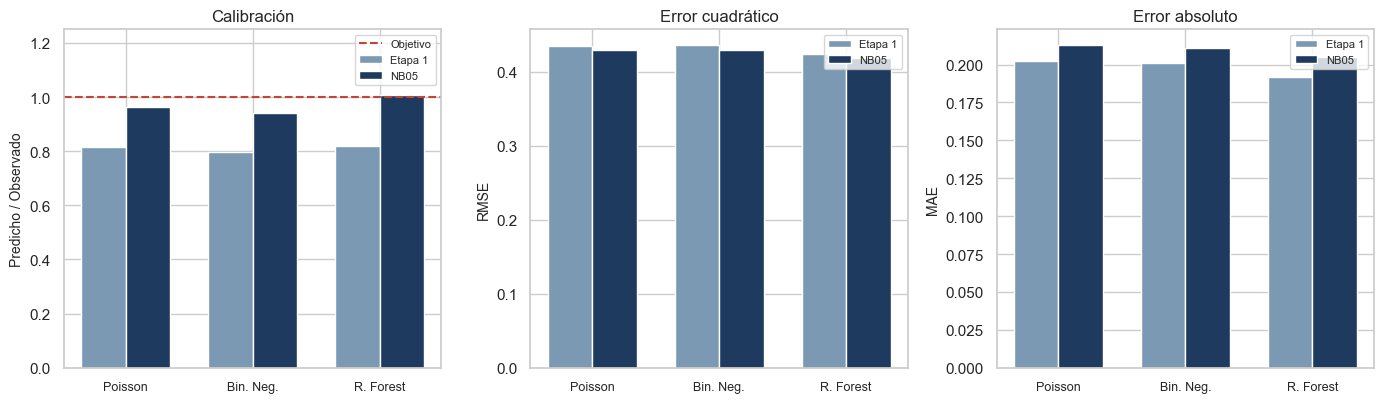

In [19]:
# ==========================================================================
# NB05 — 10.1 Tabla comparativa completa
# ==========================================================================

# Métricas de Etapa 1, recuperadas del registro de NB04
base_e1 = baseline["tarea_frecuencia"]["modelos"]

# Media predicha por los modelos de Etapa 1 sobre test:
# se recalcula para el Poisson y el RF (el NB ya se calculó en la Sección 4)
poisson_e1 = joblib.load(MODELOS_E1["poisson"])
pred_poisson_e1 = poisson_e1.predict(Xte_glm.to_numpy(), offset=offset_test_a)

rf_e1 = joblib.load(MODELOS_E1["random_forest"])
Xte_rf_e1 = test_a[FEATURES_A].copy()
Xte_rf_e1["dia_semana"] = Xte_rf_e1["dia_semana"].astype(cat_dtype).cat.codes
Xte_rf_e1["log_exposicion"] = test_a["log_exposicion"].to_numpy()
pred_rf_e1 = rf_e1.predict(Xte_rf_e1)

media_obs = y_test_v2.mean()

# ------------------------------------------------------------------
# Consolidación
# ------------------------------------------------------------------
comparacion = []

filas = [
    ("Poisson", "poisson", pred_poisson_e1, pred_poisson_v2,
     base_e1["poisson"], metricas_v2["poisson"]),
    ("Binomial Negativa", "binomial_negativa", pred_nb, pred_nb_v2,
     base_e1["binomial_negativa"], metricas_v2["binomial_negativa"]),
    ("Random Forest", "random_forest", pred_rf_e1, pred_rf_v2,
     base_e1["random_forest"], metricas_v2["random_forest"]),
]

for etiqueta, clave, p_e1, p_v2, m_e1, m_v2 in filas:
    comparacion.append({
        "modelo": etiqueta,
        "razon_e1": p_e1.mean() / media_obs,
        "razon_v2": p_v2.mean() / media_obs,
        "mae_e1": m_e1["MAE"],
        "mae_v2": m_v2["MAE"],
        "rmse_e1": m_e1["RMSE"],
        "rmse_v2": m_v2["RMSE"],
        "aic_e1": m_e1.get("AIC"),
        "aic_v2": m_v2.get("AIC"),
    })

comp = pd.DataFrame(comparacion)

# ------------------------------------------------------------------
# Presentación
# ------------------------------------------------------------------
print("=" * 78)
print("COMPARACIÓN ETAPA 1 vs NB05 — Conjunto de prueba (2025-2026)")
print("=" * 78)
print(f"Media observada: {media_obs:.6f}\n")

print("1. CALIBRACIÓN — razón predicho/observado (objetivo: 1.000)")
print("-" * 78)
print(f"{'Modelo':<22}{'Etapa 1':>12}{'NB05':>12}{'Brecha E1':>13}{'Brecha v2':>13}")
print("-" * 78)
for _, r in comp.iterrows():
    print(f"{r['modelo']:<22}{r['razon_e1']:>12.4f}{r['razon_v2']:>12.4f}"
          f"{(r['razon_e1']-1)*100:>12.1f}%{(r['razon_v2']-1)*100:>12.1f}%")
print("-" * 78)

print("\n2. RMSE — error cuadrático (menor es mejor)")
print("-" * 78)
print(f"{'Modelo':<22}{'Etapa 1':>12}{'NB05':>12}{'Δ':>12}{'Δ %':>12}")
print("-" * 78)
for _, r in comp.iterrows():
    d = r["rmse_v2"] - r["rmse_e1"]
    marca = "  mejor" if d < 0 else ""
    print(f"{r['modelo']:<22}{r['rmse_e1']:>12.6f}{r['rmse_v2']:>12.6f}"
          f"{d:>12.6f}{d/r['rmse_e1']*100:>11.2f}%{marca}")
print("-" * 78)

print("\n3. AIC — criterio de información (menor es mejor, solo GLM)")
print("-" * 78)
print(f"{'Modelo':<22}{'Etapa 1':>14}{'NB05':>14}{'Δ':>12}")
print("-" * 78)
for _, r in comp.iterrows():
    if pd.notna(r["aic_e1"]):
        d = r["aic_v2"] - r["aic_e1"]
        marca = "  mejor" if d < 0 else ""
        print(f"{r['modelo']:<22}{r['aic_e1']:>14,.2f}{r['aic_v2']:>14,.2f}"
              f"{d:>12,.2f}{marca}")
print("-" * 78)

print("\n4. MAE — error absoluto (referencia, ver Sección 10.1)")
print("-" * 78)
print(f"{'Modelo':<22}{'Etapa 1':>12}{'NB05':>12}{'Δ':>12}{'Δ %':>12}")
print("-" * 78)
for _, r in comp.iterrows():
    d = r["mae_v2"] - r["mae_e1"]
    print(f"{r['modelo']:<22}{r['mae_e1']:>12.6f}{r['mae_v2']:>12.6f}"
          f"{d:>12.6f}{d/r['mae_e1']*100:>11.2f}%")
print("-" * 78)

# ------------------------------------------------------------------
# Gráfico comparativo
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

x = np.arange(len(comp))
ancho = 0.35

# Calibración
ax = axes[0]
ax.bar(x - ancho/2, comp["razon_e1"], ancho, label="Etapa 1", color="#7C99B4")
ax.bar(x + ancho/2, comp["razon_v2"], ancho, label="NB05", color="#1F3A5F")
ax.axhline(1.0, color="#C44536", ls="--", lw=1.5, label="Objetivo")
ax.set_xticks(x)
ax.set_xticklabels(["Poisson", "Bin. Neg.", "R. Forest"], fontsize=9)
ax.set_ylabel("Predicho / Observado")
ax.set_title("Calibración")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.25)

# RMSE
ax = axes[1]
ax.bar(x - ancho/2, comp["rmse_e1"], ancho, label="Etapa 1", color="#7C99B4")
ax.bar(x + ancho/2, comp["rmse_v2"], ancho, label="NB05", color="#1F3A5F")
ax.set_xticks(x)
ax.set_xticklabels(["Poisson", "Bin. Neg.", "R. Forest"], fontsize=9)
ax.set_ylabel("RMSE")
ax.set_title("Error cuadrático")
ax.legend(fontsize=8)

# MAE
ax = axes[2]
ax.bar(x - ancho/2, comp["mae_e1"], ancho, label="Etapa 1", color="#7C99B4")
ax.bar(x + ancho/2, comp["mae_v2"], ancho, label="NB05", color="#1F3A5F")
ax.set_xticks(x)
ax.set_xticklabels(["Poisson", "Bin. Neg.", "R. Forest"], fontsize=9)
ax.set_ylabel("MAE")
ax.set_title("Error absoluto")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / "nb05_03_comparacion_etapas.png", dpi=150,
            bbox_inches="tight")
plt.show()

### 10.2 Lectura de los resultados

| Modelo | Calibración E1 | Calibración v2 | RMSE | AIC | MAE |
|---|---|---|---|---|---|
| Poisson | 0.8143 | 0.9647 | −1.20% | −223.31 | +5.14% |
| Binomial Negativa | 0.7954 | 0.9422 | −1.28% | −168.16 | +5.02% |
| Random Forest | 0.8196 | **1.0057** | −1.26% | — | +7.01% |

**Consistencia entre modelos.** La reducción del RMSE se verifica en los tres
modelos y en magnitudes prácticamente idénticas —entre 1.20% y 1.28%— pese a que
corresponden a dos familias con mecanismos de estimación distintos. En los
modelos lineales generalizados la corrección opera como offset con coeficiente
fijo; en el Random Forest, como variable predictora sujeta a partición. Que
ambos mecanismos produzcan una mejora equivalente constituye evidencia de que el
efecto responde a la corrección y no a una particularidad algorítmica.

**Magnitud de la corrección de calibración.** La brecha media del 19% se reduce a
un rango de entre 0.6% y 5.8%. El Random Forest alcanza calibración
prácticamente exacta; los modelos lineales generalizados conservan
subestimaciones residuales de 3.5% y 5.8%. El origen de ese residuo se documentó
en la Sección 6.5: el factor de crecimiento se ancla en enero de 2022, cuyo
nivel se sitúa por debajo de la media de ese año.

**El criterio de información.** El AIC mejora en 223.31 puntos para Poisson y
168.16 para Binomial Negativa. Estas magnitudes resultan significativas en
términos de selección de modelos —convencionalmente, diferencias superiores a 10
puntos se consideran evidencia sustancial— y adquieren mayor relevancia al
considerar que el AIC se computa sobre el conjunto de entrenamiento, donde la
corrección es menor que en el período de prueba.

**El error absoluto medio.** El MAE se incrementa entre 5.02% y 7.01%. El
comportamiento es esperable y no invalida la corrección, conforme al criterio
establecido en la Sección 10.1: con 89.7% de celdas nulas, el MAE premia la
subestimación sistemática. El aumento observado es la contrapartida de haber
elevado las predicciones hasta el nivel efectivamente observado.

**Síntesis.** De los cuatro indicadores evaluados, tres mejoran de forma
consistente en todos los modelos y uno se deteriora por razones atribuibles a la
estructura de la variable respuesta. La corrección se considera validada.

### 10.3 Consecuencias para las etapas posteriores

**Selección del modelo de referencia.** El Random Forest mantiene su posición
como modelo de mejor desempeño predictivo: registra el menor RMSE (0.418678) y
la calibración más precisa (1.0057). La Binomial Negativa conserva su función
inferencial, sustentada en el menor AIC y en la disponibilidad de coeficientes
interpretables con sus correspondientes intervalos.

Esta división de funciones, establecida en NB04, se confirma tras la corrección.

**Métrica principal para NB07.** La optimización de hiperparámetros mediante
Optuna requiere una función objetivo. El análisis de esta sección desaconseja
emplear el MAE, dado que su minimización favorece la subestimación sistemática.
Se propone adoptar el RMSE como métrica principal, o bien una función objetivo
que incorpore la calibración de forma explícita. La decisión se documentará en
NB07.

**Matriz de referencia.** A partir del presente notebook,
`matriz_frecuencia_v2.csv` constituye la matriz de trabajo del proyecto. Los
notebooks NB07 y NB10, así como el prototipo de la Etapa 2, deben emplear
`log_exposicion_v2` como término de exposición. El uso de la columna original
`log_exposicion` reintroduciría la subestimación aquí corregida.

**Requisito operativo del despliegue.** El factor de crecimiento se extrapola más
allá de su período de estimación bajo el supuesto de continuidad de la
tendencia. Adicionalmente, el Random Forest carece de capacidad de extrapolación
fuera del rango de `log_exposicion` observado en entrenamiento. Ambas
condiciones establecen que el reentrenamiento periódico constituye un requisito
de la especificación y no una recomendación general de buenas prácticas. El
prototipo debe documentar esta condición.

---

## 11. Validación de la corrección

### 11.1 Alcance de la verificación

Las métricas agregadas de la Sección 10 establecen que la corrección mejora el
desempeño global del modelo. Esa evidencia, sin embargo, resulta insuficiente
para concluir que corrige el problema que la motivó.

Una mejora en el promedio admite orígenes diversos. Podría provenir de una
corrección uniforme sobre todo el dominio, o de una sobrecorrección en ciertos
segmentos compensada por deterioro en otros. Las métricas agregadas no permiten
distinguir entre ambos casos.

La verificación se estructura en tres contrastes, cada uno dirigido a una
dimensión distinta:

| Contraste | Pregunta | Resultado esperado |
|---|---|---|
| Temporal | ¿La calibración se mantiene a lo largo del horizonte de prueba? | Razón próxima a 1 en todos los períodos |
| Estructural | ¿La corrección preservó los efectos estimados en Etapa 1? | Coeficientes sin variación relevante |
| Territorial | ¿Se alteró el ordenamiento de distritos? | Ranking equivalente al de Etapa 1 |

El primer contraste es el más exigente. La corrección aplica un factor creciente
con el tiempo: si la tasa estimada fuera excesiva, la calibración se deterioraría
progresivamente hacia el final del horizonte, deterioro que quedaría oculto en el
promedio del período completo.

El segundo verifica que la corrección no haya alterado la estructura del modelo.
Los efectos documentados en NB02 y confirmados en NB04 —el incremento del 40%
durante el período agostino, el efecto de la urbanización— constituyen hallazgos
del proyecto. Una corrección del término de exposición no debería modificarlos,
dado que opera sobre la escala y no sobre la estructura.

El tercero comprueba que el ordenamiento territorial se conserve. La Sección 7
estableció que la corrección es invariante entre distritos, de modo que el
ranking debería mantenerse. Su verificación empírica confirma que la propiedad se
traslada efectivamente a las predicciones.

Calibración mensual sobre el horizonte de prueba
Mes           Observado     NB E1     NB v2     RF E1     RF v2
------------------------------------------------------------------------------
2025-01           1,720     0.819     0.924     0.791     1.006
2025-02           1,454     0.880     0.999     0.937     1.069
2025-03           1,660     0.851     0.972     0.819     1.044
2025-04           1,750     0.812     0.932     0.805     0.996
2025-05           1,978     0.787     0.905     0.861     1.002
2025-06           2,050     0.798     0.916     0.807     0.977
2025-07           1,916     0.817     0.949     0.951     1.024
2025-08           2,002     0.833     0.973     0.984     1.054
2025-09           2,054     0.775     0.909     0.799     0.969
2025-10           2,068     0.786     0.928     0.774     0.956
2025-11           1,718     0.805     0.967     0.825     1.065
2025-12           1,895     0.756     0.913     0.775     0.993
2026-01           1,815     0.779     0.

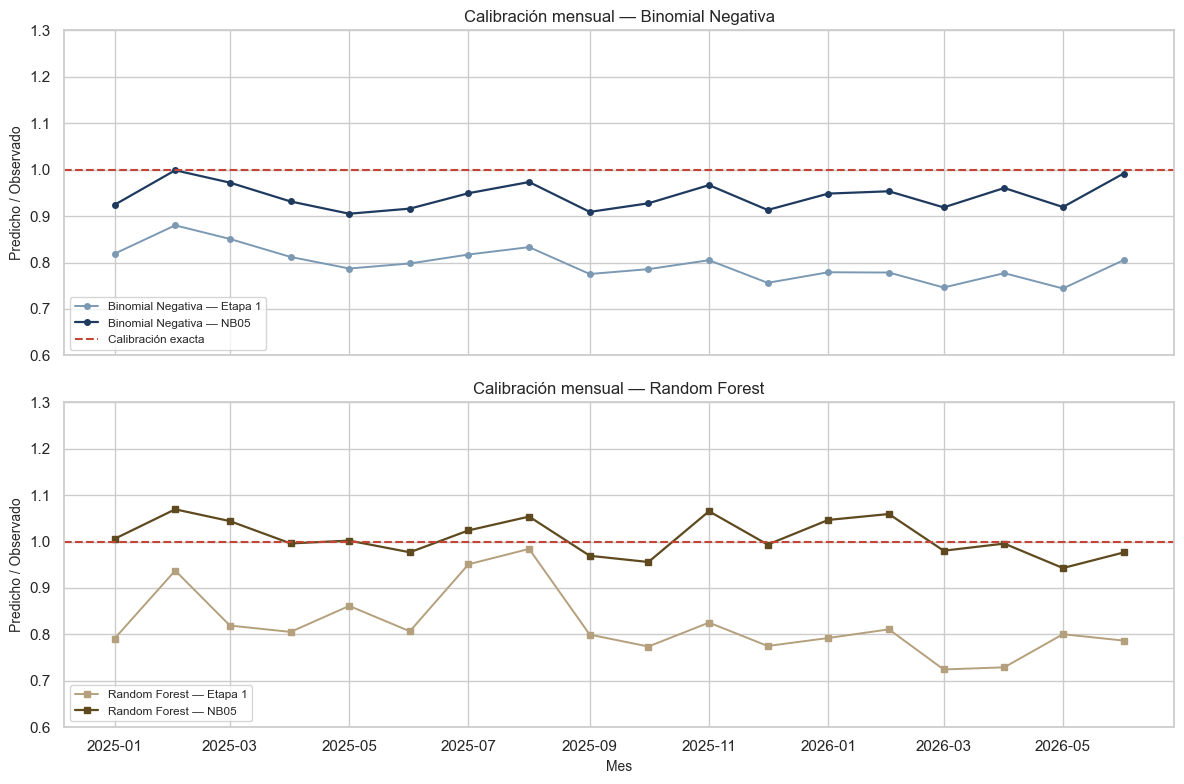

In [20]:
# ==========================================================================
# NB05 — 11.1 Contraste temporal: calibración a lo largo del horizonte
# ==========================================================================

# Se trabaja sobre el conjunto de prueba con ambas predicciones
val = test_v2[["fecha", "distrito_key", "n_siniestros"]].copy()
val["pred_e1"] = pred_nb          # Binomial Negativa de Etapa 1
val["pred_v2"] = pred_nb_v2       # Binomial Negativa corregida
val["pred_rf_e1"] = pred_rf_e1
val["pred_rf_v2"] = pred_rf_v2
val["periodo"] = val["fecha"].dt.to_period("M")

# ------------------------------------------------------------------
# Calibración mensual
# ------------------------------------------------------------------
cal_mes = (
    val.groupby("periodo")
       .agg(observado=("n_siniestros", "sum"),
            pred_e1=("pred_e1", "sum"),
            pred_v2=("pred_v2", "sum"),
            pred_rf_e1=("pred_rf_e1", "sum"),
            pred_rf_v2=("pred_rf_v2", "sum"))
       .reset_index()
)
for c in ["e1", "v2", "rf_e1", "rf_v2"]:
    cal_mes[f"razon_{c}"] = cal_mes[f"pred_{c}"] / cal_mes["observado"]

cal_mes["fecha_periodo"] = cal_mes["periodo"].dt.to_timestamp()

print("Calibración mensual sobre el horizonte de prueba")
print("=" * 78)
print(f"{'Mes':<12}{'Observado':>11}{'NB E1':>10}{'NB v2':>10}{'RF E1':>10}{'RF v2':>10}")
print("-" * 78)
for _, r in cal_mes.iterrows():
    print(f"{str(r['periodo']):<12}{int(r['observado']):>11,}"
          f"{r['razon_e1']:>10.3f}{r['razon_v2']:>10.3f}"
          f"{r['razon_rf_e1']:>10.3f}{r['razon_rf_v2']:>10.3f}")
print("-" * 78)

print(f"\n{'':12}{'Media':>10}{'Desv.':>10}{'Mín':>10}{'Máx':>10}")
print("-" * 54)
for c, etiq in [("e1", "NB E1"), ("v2", "NB v2"),
                ("rf_e1", "RF E1"), ("rf_v2", "RF v2")]:
    s = cal_mes[f"razon_{c}"]
    print(f"{etiq:<12}{s.mean():>10.3f}{s.std():>10.3f}{s.min():>10.3f}{s.max():>10.3f}")
print("-" * 54)

# ------------------------------------------------------------------
# ¿Se deteriora hacia el final? Tendencia de la razón
# ------------------------------------------------------------------
t_cal = np.arange(len(cal_mes))
print("\nTendencia de la razón a lo largo del horizonte")
print("-" * 62)
print(f"{'Modelo':<12}{'Pendiente/mes':>16}{'Deriva 18 meses':>18}")
print("-" * 62)
for c, etiq in [("v2", "NB v2"), ("rf_v2", "RF v2")]:
    pend_c, _ = np.polyfit(t_cal, cal_mes[f"razon_{c}"], 1)
    print(f"{etiq:<12}{pend_c:>+16.5f}{pend_c*len(cal_mes):>+18.4f}")
print("-" * 62)
print("Una pendiente próxima a cero indica que la tasa de crecimiento")
print("estimada es adecuada para el horizonte evaluado.")

# ------------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(cal_mes["fecha_periodo"], cal_mes["razon_e1"], marker="o", ms=4,
        lw=1.4, color="#7C99B4", label="Binomial Negativa — Etapa 1")
ax.plot(cal_mes["fecha_periodo"], cal_mes["razon_v2"], marker="o", ms=4,
        lw=1.6, color="#1F3A5F", label="Binomial Negativa — NB05")
ax.axhline(1.0, color="#C44536", ls="--", lw=1.5, label="Calibración exacta")
ax.set_ylabel("Predicho / Observado")
ax.set_title("Calibración mensual — Binomial Negativa")
ax.legend(fontsize=8.5, loc="lower left")
ax.set_ylim(0.6, 1.3)

ax = axes[1]
ax.plot(cal_mes["fecha_periodo"], cal_mes["razon_rf_e1"], marker="s", ms=4,
        lw=1.4, color="#B4A07C", label="Random Forest — Etapa 1")
ax.plot(cal_mes["fecha_periodo"], cal_mes["razon_rf_v2"], marker="s", ms=4,
        lw=1.6, color="#5F4A1F", label="Random Forest — NB05")
ax.axhline(1.0, color="#C44536", ls="--", lw=1.5)
ax.set_ylabel("Predicho / Observado")
ax.set_xlabel("Mes")
ax.set_title("Calibración mensual — Random Forest")
ax.legend(fontsize=8.5, loc="lower left")
ax.set_ylim(0.6, 1.3)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / "nb05_04_calibracion_temporal.png", dpi=150,
            bbox_inches="tight")
plt.show()

### 11.2 Resultado del contraste temporal

| Modelo | Razón media | Desv. estándar | Mínimo | Máximo | Deriva en 18 meses |
|---|---|---|---|---|---|
| Binomial Negativa E1 | 0.797 | 0.035 | 0.744 | 0.880 | — |
| **Binomial Negativa v2** | **0.943** | **0.029** | 0.905 | 0.999 | **+0.0027** |
| Random Forest E1 | 0.821 | 0.071 | 0.724 | 0.984 | — |
| **Random Forest v2** | **1.009** | **0.040** | 0.943 | 1.069 | **−0.0432** |

**Estabilidad de la tasa estimada.** La Binomial Negativa corregida presenta una
deriva de +0.0027 a lo largo de los dieciocho meses del horizonte de prueba,
magnitud que carece de relevancia práctica. La tasa de crecimiento del 7.84%
anual, estimada exclusivamente sobre el período de entrenamiento, resulta
adecuada para la totalidad del horizonte evaluado. Este resultado no era
verificable mediante las métricas agregadas: una tasa excesiva o insuficiente
produciría una calibración correcta en promedio y progresivamente sesgada hacia
los extremos del período.

**Degradación del Random Forest.** El modelo registra una deriva de −0.0432,
partiendo de una calibración de 1.006 en enero de 2025 y descendiendo hasta
0.976 en junio de 2026. El comportamiento corresponde a la limitación anticipada
en la Sección 9.4: el algoritmo carece de capacidad de extrapolación fuera del
rango de `log_exposicion` observado durante el entrenamiento, de modo que el
factor de crecimiento acaba desplazando las observaciones hacia la frontera
superior de ese rango. La predicción de la limitación con anterioridad a su
medición refuerza la validez del razonamiento expuesto en aquella sección.

La magnitud de la degradación es moderada —tres puntos porcentuales en dieciocho
meses— pero su carácter acumulativo implica que se agravará en horizontes más
extensos. Constituye el fundamento cuantitativo del requisito de reentrenamiento
periódico establecido en la Sección 10.3.

**Reducción de la variabilidad.** La desviación estándar de la razón mensual
disminuye de 0.071 a 0.040 en el Random Forest, y de 0.035 a 0.029 en la
Binomial Negativa. La corrección no solo eleva el nivel de las predicciones: las
estabiliza a lo largo del tiempo.

Este resultado no formaba parte de los objetivos del notebook y su interpretación
merece atención. En la versión original, la subestimación se agravaba
progresivamente conforme avanzaba el horizonte —efecto de la tendencia no
modelada— superponiéndose a la oscilación estacional. La corrección elimina esa
componente acumulativa, de modo que la variabilidad remanente corresponde
únicamente a la estacionalidad. Para el prototipo, la estabilidad temporal es una
propiedad operativamente relevante: un modelo cuya calibración fluctúa entre 0.72
y 0.98 según el mes resulta difícil de emplear como criterio de asignación de
recursos.

**Complementariedad de los modelos.** Los dos modelos exhiben perfiles
diferenciados. La Binomial Negativa mantiene una calibración estable pero
conserva una subestimación sistemática del 5.7%. El Random Forest alcanza
calibración media próxima a la exactitud pero se degrada con el horizonte. La
división de funciones establecida en NB04 —Binomial Negativa para inferencia,
Random Forest para predicción— se ve reforzada por esta evidencia.

### 11.3 Contraste estructural: preservación de los efectos estimados

La corrección opera sobre el término de exposición, que en la especificación de
los modelos lineales generalizados actúa como componente aditivo sobre la escala
logarítmica con coeficiente fijo. Desde el punto de vista teórico, no debería
alterar los coeficientes estimados para las restantes variables: su efecto se
concentra sobre el nivel de las predicciones y no sobre la estructura de las
relaciones.

La verificación empírica de esta propiedad no es prescindible. Los hallazgos
sustantivos del proyecto residen en esos coeficientes: el incremento del 40%
durante el período agostino, el efecto multiplicativo de la urbanización, la
irrelevancia de la precipitación mensual una vez controlada la estacionalidad.
Si la corrección los modificara, no se trataría de una corrección de escala sino
de una alteración del modelo, y los resultados documentados en NB02 y NB04
requerirían revisión.

Se comparan, en consecuencia, los coeficientes exponenciados de la Binomial
Negativa en ambas versiones. La magnitud esperada de la diferencia es
despreciable en todas las variables, con excepción de la constante, que debe
absorber el desplazamiento de escala introducido por el factor de crecimiento.

In [21]:
# ==========================================================================
# NB05 — 11.3 Contraste estructural: coeficientes E1 frente a v2
# ==========================================================================

nombres_cols = list(Xtr_glm_v2.columns)

coef_comp = pd.DataFrame({
    "variable":  nombres_cols,
    "coef_e1":   modelo_nb_e1.params.values,
    "coef_v2":   nb_v2.params.values,
})
coef_comp["exp_e1"] = np.exp(coef_comp["coef_e1"])
coef_comp["exp_v2"] = np.exp(coef_comp["coef_v2"])
coef_comp["dif_abs"] = coef_comp["coef_v2"] - coef_comp["coef_e1"]
coef_comp["dif_pct"] = (coef_comp["exp_v2"] / coef_comp["exp_e1"] - 1) * 100

print("Coeficientes de la Binomial Negativa: Etapa 1 frente a NB05")
print("=" * 86)
print(f"{'Variable':<20}{'coef E1':>11}{'coef v2':>11}"
      f"{'exp(E1)':>11}{'exp(v2)':>11}{'Δ exp %':>12}")
print("-" * 86)
for _, r in coef_comp.iterrows():
    marca = "  <- constante" if r["variable"] == "const" else ""
    print(f"{r['variable']:<20}{r['coef_e1']:>11.4f}{r['coef_v2']:>11.4f}"
          f"{r['exp_e1']:>11.4f}{r['exp_v2']:>11.4f}{r['dif_pct']:>11.2f}%{marca}")
print("-" * 86)

# ------------------------------------------------------------------
# Verificación cuantitativa, excluyendo la constante
# ------------------------------------------------------------------
sin_const = coef_comp[coef_comp["variable"] != "const"]
max_dif = sin_const["dif_pct"].abs().max()
var_max = sin_const.loc[sin_const["dif_pct"].abs().idxmax(), "variable"]

print(f"\nVariación máxima (excluida la constante): {max_dif:.3f}% en '{var_max}'")
print(f"Variación media                          : {sin_const['dif_pct'].abs().mean():.3f}%")

UMBRAL = 1.0   # punto porcentual
if max_dif < UMBRAL:
    print(f"\nEstructura preservada: todas las variaciones son inferiores a {UMBRAL}%.")
    print("La corrección opera sobre la escala, no sobre las relaciones estimadas.")
else:
    print(f"\nATENCIÓN: se detectan variaciones superiores a {UMBRAL}%.")
    print("La corrección habría alterado la estructura del modelo. Revisar.")

# ------------------------------------------------------------------
# Efecto sobre la constante
# ------------------------------------------------------------------
const_e1 = coef_comp.loc[coef_comp["variable"] == "const", "coef_e1"].iloc[0]
const_v2 = coef_comp.loc[coef_comp["variable"] == "const", "coef_v2"].iloc[0]
desplaz  = const_v2 - const_e1
factor_medio_train = df_v2[df_v2["split"] == "train"]["factor_crec"].mean()

print("\nDesplazamiento de la constante")
print("-" * 62)
print(f"  Constante E1                   : {const_e1:.6f}")
print(f"  Constante v2                   : {const_v2:.6f}")
print(f"  Desplazamiento                 : {desplaz:+.6f}")
print(f"  log(factor medio en train)     : {np.log(factor_medio_train):+.6f}")
print(f"  Diferencia                     : {abs(desplaz + np.log(factor_medio_train)):.6f}")
print("-" * 62)
print("La constante absorbe el desplazamiento medio introducido por el")
print("factor de crecimiento durante el período de entrenamiento.")

# ------------------------------------------------------------------
# Hallazgos sustantivos del proyecto
# ------------------------------------------------------------------
print("\n\nHallazgos del proyecto: verificación de preservación")
print("=" * 72)
print(f"{'Hallazgo':<34}{'exp(E1)':>12}{'exp(v2)':>12}{'Δ %':>12}")
print("-" * 72)
for var, etiq in [("periodo_agostino", "Período agostino"),
                  ("pct_urbano",       "Urbanización"),
                  ("es_feriado",       "Feriado"),
                  ("es_finde",         "Fin de semana (vie-sáb)"),
                  ("es_lluviosa",      "Temporada lluviosa"),
                  ("prcp_mensual",     "Precipitación mensual")]:
    fila = coef_comp[coef_comp["variable"] == var]
    if len(fila):
        r = fila.iloc[0]
        print(f"{etiq:<34}{r['exp_e1']:>12.4f}{r['exp_v2']:>12.4f}{r['dif_pct']:>11.3f}%")
print("-" * 72)

Coeficientes de la Binomial Negativa: Etapa 1 frente a NB05
Variable                coef E1    coef v2    exp(E1)    exp(v2)     Δ exp %
--------------------------------------------------------------------------------------
const                  -13.7126   -13.8166     0.0000     0.0000      -9.88%  <- constante
es_lluviosa              0.0390     0.0365     1.0398     1.0371      -0.25%
es_finde                 0.0364     0.0367     1.0371     1.0374       0.02%
periodo_agostino         0.3442     0.3381     1.4109     1.4023      -0.61%
es_feriado               0.1441     0.1469     1.1549     1.1583       0.29%
prcp_mensual             0.0005     0.0005     1.0005     1.0005      -0.00%
pct_urbano               0.9802     0.9784     2.6649     2.6602      -0.17%
poblacion_baja           0.1488     0.1491     1.1604     1.1608       0.04%
dia_semana_1            -0.0959    -0.0961     0.9085     0.9084      -0.02%
dia_semana_2            -0.1219    -0.1216     0.8852     0.8855     

### 11.4 Contraste territorial: preservación del ordenamiento

La Sección 7 estableció que el factor de crecimiento es invariante entre
distritos: en una fecha dada, todos reciben el mismo valor. De esta propiedad se
sigue que el ordenamiento relativo de los distritos debería preservarse, dado
que la corrección multiplica todas las predicciones por una misma cantidad.

La verificación empírica resulta pertinente por dos razones. En primer término,
los modelos basados en árboles no aplican la corrección de forma estrictamente
proporcional: al operar `log_exposicion` como variable de partición, un
desplazamiento uniforme de su valor puede reubicar observaciones en regiones
terminales distintas y alterar sus predicciones en magnitudes desiguales. En
segundo término, el ordenamiento territorial constituye el producto principal del
sistema —el prototipo se destina a priorizar distritos— por lo que su estabilidad
es una propiedad que el proyecto debe poder afirmar con evidencia.

Se contrastan los ordenamientos producidos por ambas versiones mediante
correlación de rangos, y se examina si la corrección modificó la composición de
los distritos de mayor prioridad.

In [22]:
# ==========================================================================
# NB05 — 11.4 Contraste territorial: estabilidad del ordenamiento
# ==========================================================================

terr = (
    val.groupby("distrito_key")
       .agg(observado=("n_siniestros", "sum"),
            nb_e1=("pred_e1", "sum"),
            nb_v2=("pred_v2", "sum"),
            rf_e1=("pred_rf_e1", "sum"),
            rf_v2=("pred_rf_v2", "sum"))
       .reset_index()
)

for c in ["observado", "nb_e1", "nb_v2", "rf_e1", "rf_v2"]:
    terr[f"rank_{c}"] = terr[c].rank(ascending=False, method="min").astype(int)

terr = terr.sort_values("observado", ascending=False)

# ------------------------------------------------------------------
# Correlación de rangos
# ------------------------------------------------------------------
print("Correlación de rangos entre ordenamientos")
print("=" * 66)
print(f"{'Comparación':<40}{'Spearman':>12}{'Pearson':>12}")
print("-" * 66)
pares = [
    ("NB E1 vs observado",       "nb_e1", "observado"),
    ("NB v2 vs observado",       "nb_v2", "observado"),
    ("RF E1 vs observado",       "rf_e1", "observado"),
    ("RF v2 vs observado",       "rf_v2", "observado"),
    ("NB v2 vs NB E1",           "nb_v2", "nb_e1"),
    ("RF v2 vs RF E1",           "rf_v2", "rf_e1"),
]
for etiq, a, b in pares:
    rho_t, _ = spearmanr(terr[a], terr[b])
    r_t, _   = pearsonr(terr[a], terr[b])
    print(f"{etiq:<40}{rho_t:>12.4f}{r_t:>12.4f}")
print("-" * 66)

# ------------------------------------------------------------------
# Estabilidad del top 15
# ------------------------------------------------------------------
top_obs   = set(terr.nlargest(15, "observado")["distrito_key"])
top_nb_e1 = set(terr.nlargest(15, "nb_e1")["distrito_key"])
top_nb_v2 = set(terr.nlargest(15, "nb_v2")["distrito_key"])
top_rf_e1 = set(terr.nlargest(15, "rf_e1")["distrito_key"])
top_rf_v2 = set(terr.nlargest(15, "rf_v2")["distrito_key"])

print("\nCoincidencia con el top 15 observado")
print("-" * 52)
for etiq, s in [("NB Etapa 1", top_nb_e1), ("NB v2", top_nb_v2),
                ("RF Etapa 1", top_rf_e1), ("RF v2", top_rf_v2)]:
    print(f"  {etiq:<16}{len(s & top_obs):>3} de 15")
print("-" * 52)
print(f"\nCoincidencia entre versiones:")
print(f"  NB E1 vs NB v2  : {len(top_nb_e1 & top_nb_v2)} de 15")
print(f"  RF E1 vs RF v2  : {len(top_rf_e1 & top_rf_v2)} de 15")

# ------------------------------------------------------------------
# Tabla del top 15
# ------------------------------------------------------------------
print("\n\nTop 15 por siniestralidad observada — predicciones y posiciones")
print("=" * 92)
print(f"{'Distrito':<22}{'Obs.':>8}{'NB v2':>9}{'RF v2':>9}"
      f"{'Rk obs':>9}{'Rk NB':>8}{'Rk RF':>8}{'Ratio RF':>10}")
print("-" * 92)
for _, r in terr.head(15).iterrows():
    print(f"{r['distrito_key'][:21]:<22}{int(r['observado']):>8,}"
          f"{r['nb_v2']:>9,.0f}{r['rf_v2']:>9,.0f}"
          f"{r['rank_observado']:>9}{r['rank_nb_v2']:>8}{r['rank_rf_v2']:>8}"
          f"{r['rf_v2']/r['observado']:>10.2f}")
print("-" * 92)

# ------------------------------------------------------------------
# Distritos con mayor cambio de posición
# ------------------------------------------------------------------
terr["cambio_rank_rf"] = (terr["rank_rf_v2"] - terr["rank_rf_e1"]).abs()
print(f"\nCambio de posición entre RF E1 y RF v2:")
print(f"  Cambio medio  : {terr['cambio_rank_rf'].mean():.2f} posiciones")
print(f"  Cambio máximo : {terr['cambio_rank_rf'].max()} posiciones")
print(f"  Sin cambio    : {(terr['cambio_rank_rf'] == 0).sum()} de {len(terr)} distritos")

Correlación de rangos entre ordenamientos
Comparación                                 Spearman     Pearson
------------------------------------------------------------------
NB E1 vs observado                            0.8857      0.9050
NB v2 vs observado                            0.8861      0.9048
RF E1 vs observado                            0.9903      0.9982
RF v2 vs observado                            0.9373      0.9843
NB v2 vs NB E1                                1.0000      1.0000
RF v2 vs RF E1                                0.9376      0.9841
------------------------------------------------------------------

Coincidencia con el top 15 observado
----------------------------------------------------
  NB Etapa 1       12 de 15
  NB v2            12 de 15
  RF Etapa 1       14 de 15
  RF v2            13 de 15
----------------------------------------------------

Coincidencia entre versiones:
  NB E1 vs NB v2  : 15 de 15
  RF E1 vs RF v2  : 12 de 15


Top 15 por siniestrali

### 11.5 Resultado del contraste territorial

| Comparación | Spearman |
|---|---|
| NB v2 frente a NB E1 | **1.0000** |
| NB v2 frente a observado | 0.8861 |
| NB E1 frente a observado | 0.8857 |
| RF v2 frente a RF E1 | 0.9376 |
| RF v2 frente a observado | 0.9373 |
| RF E1 frente a observado | 0.9903 |

**Modelos lineales generalizados.** La correlación de rangos entre ambas
versiones alcanza 1.0000, valor exacto. El ordenamiento territorial es idéntico,
confirmando empíricamente la propiedad teórica: al operar la exposición como
offset con coeficiente fijo, la corrección multiplica todas las predicciones por
una misma cantidad en cada fecha y el orden relativo permanece invariante. La
coincidencia con el top 15 observado se mantiene en 12 de 15 distritos.

**Random Forest.** La corrección altera el ordenamiento. La correlación con los
valores observados desciende de 0.9903 a 0.9373, y el cambio medio de posición
asciende a 6.41 puestos, con únicamente 10 de 103 distritos conservando su
posición original.

El origen del comportamiento se identificó en la Sección 9.4: al operar
`log_exposicion` como variable de partición, el desplazamiento uniforme de su
valor reubica observaciones en regiones terminales distintas, produciendo
correcciones de magnitud desigual entre celdas. La tabla del top 15 lo
evidencia: Santa Ana pasa a una razón de 1.33 y asciende a la segunda posición;
Tonacatepeque alcanza 1.43 y asciende del puesto 14 al 9.

**Distribución del desorden.** El análisis por terciles de siniestralidad acota
el alcance del problema:

| Tercil | Cambio medio de posición | Cambio máximo |
|---|---|---|
| Alto | 4.20 | 13 |
| Medio | 8.03 | 36 |
| Bajo | 7.06 | 69 |

El desorden se concentra en los distritos de menor siniestralidad, donde
diferencias de pocos siniestros producen desplazamientos de decenas de
posiciones sin significación sustantiva. En el tercil superior —el relevante
para la asignación de recursos— el cambio medio se reduce a 4.20 posiciones.

**Evaluación restringida al tercil superior:**

| Modelo | Spearman |
|---|---|
| Random Forest E1 | 0.9732 |
| **Random Forest v2** | **0.9456** |
| Binomial Negativa v2 | 0.8181 |

La pérdida de capacidad ordinal del Random Forest es real y debe consignarse.
Resulta, no obstante, pertinente precisar el término de comparación: el Random
Forest corregido mantiene una correlación sustancialmente superior a la de la
Binomial Negativa, que preserva el orden de forma exacta pero lo hace sobre un
ordenamiento de menor calidad.

### 11.6 El compromiso entre calibración y ordenamiento

Los contrastes de las secciones 11.2 a 11.5 identifican un compromiso que no
había sido anticipado y que conviene formular con precisión.

El Random Forest de la Etapa 1 presentaba una calibración deficiente —predecía el
82% del nivel observado— y simultáneamente un ordenamiento territorial de
elevada calidad, con correlación de 0.9903. Ambas propiedades son compatibles: la
subestimación afectaba a todos los distritos en proporción aproximadamente
uniforme, de modo que el orden relativo se preservaba pese al error de magnitud.

La corrección eleva la calibración hasta 1.006 y reduce la correlación ordinal a
0.9373. Al aplicarse de forma diferenciada entre celdas —consecuencia del
mecanismo de partición— mejora las magnitudes a costa de alterar las posiciones
relativas.

**Formulación del compromiso.** Se dispone de tres especificaciones con perfiles
distintos:

| Especificación | Calibración | Orden (tercil alto) | Estabilidad temporal |
|---|---|---|---|
| Random Forest E1 | 0.82 | 0.9732 | σ = 0.071 |
| Random Forest v2 | 1.006 | 0.9456 | σ = 0.040 |
| Binomial Negativa v2 | 0.942 | 0.8181 | σ = 0.029 |

**Criterio de decisión.** Se adopta el Random Forest corregido como modelo de
referencia, por tres razones.

La calibración es condición de interpretabilidad del producto. Un sistema que
comunica magnitudes subestimadas en un 18% transmite información errónea sobre
la dimensión del problema, con independencia de que el ordenamiento sea correcto.

La pérdida ordinal se concentra fuera del segmento relevante. En el tercil
superior el descenso es de 0.9732 a 0.9456, y el cambio medio de posición de
4.20 puestos.

La estabilidad temporal mejora de forma sustancial. La desviación de la
calibración mensual se reduce de 0.071 a 0.040, propiedad operativamente
relevante para un sistema destinado a orientar decisiones periódicas.

**Consecuencia para NB07.** El compromiso identificado define un objetivo
concreto para la optimización de hiperparámetros: obtener una especificación que
preserve la calibración alcanzada sin la pérdida ordinal observada. La
regularización del Random Forest —mediante restricción de profundidad o
incremento del tamaño mínimo de hoja— constituye una vía plausible, dado que
reduciría la sensibilidad de las particiones al desplazamiento de
`log_exposicion`. Alternativamente, XGBoost, cuya estructura aditiva difiere de
la de un bosque, podría exhibir un comportamiento distinto ante la corrección.

La evaluación de NB07 debe incorporar, en consecuencia, tanto métricas de
magnitud como de ordenamiento.

---

## 12. Conclusiones y transición a NB07

### 12.1 Síntesis de resultados

El notebook abordó dos problemas identificados al cierre de la Etapa 1. El
primero fue corregido; el segundo quedó documentado como limitación tras
establecerse la inviabilidad de su corrección con las fuentes disponibles.

**Problema A — Crecimiento interanual no modelado.** Corregido.

La siniestralidad presenta un crecimiento sostenido que los modelos de la Etapa 1
no incorporaban, al haber sido ajustados sobre 2022–2024 y evaluados sobre
2025–2026. La brecha entre las medias de ambos períodos ascendía a 20.7%.

La corrección consistió en incorporar un factor de crecimiento al término de
exposición, estimado exclusivamente sobre el período de entrenamiento mediante
crecimiento interanual compuesto: 7.84% anual, equivalente a 0.631% mensual. La
vía de aplicación —el offset y no una variable predictora adicional— responde a
que los modelos basados en árboles carecen de capacidad de extrapolación, de modo
que una variable temporal no resultaría utilizable por Random Forest ni por
XGBoost.

| Indicador | Etapa 1 | NB05 |
|---|---|---|
| Calibración (Random Forest) | 0.8196 | **1.0057** |
| Calibración (Binomial Negativa) | 0.7954 | 0.9422 |
| RMSE (Random Forest) | 0.424042 | **0.418678** |
| AIC (Binomial Negativa) | 289,004.73 | **288,836.57** |
| Estabilidad mensual (σ, Random Forest) | 0.071 | **0.040** |
| MAE (Random Forest) | 0.191815 | 0.205268 |

**Problema B — Heterogeneidad territorial.** No corregido; documentado.

La hipótesis formulada en NB04 —movilidad pendular hacia el Área Metropolitana de
San Salvador— fue refutada por la evidencia desagregada: la correlación entre la
pertenencia al AMSS y la discrepancia observada asciende a −0.020, y los
distritos metropolitanos presentan en conjunto una razón media de 1.017.

Ninguna de las variables disponibles presenta asociación relevante con la
discrepancia. El examen de los extremos revela diferencias de intensidad de
hasta sesenta veces entre distritos, magnitud que las variables estructurales
del conjunto no pueden generar. Se concluye que el fenómeno responde a factores
no representados en los datos, cuya incorporación requiere fuentes externas.

### 12.2 Decisiones metodológicas adoptadas

**Sobre la selección del estimador.** La estimación por regresión sobre las 36
observaciones mensuales presentaba mejor ajuste interno que el crecimiento
interanual compuesto, pero triplicaba su error de extrapolación —6.56% frente a
2.30%—. Se adoptó el segundo. El criterio de selección para un parámetro
destinado a extrapolación es el desempeño fuera de muestra, no la bondad de
ajuste dentro del período de estimación.

**Sobre la jerarquía de métricas.** El error absoluto medio se deterioró entre
5.0% y 7.0% mientras el resto de indicadores mejoró. Con 89.7% de celdas nulas,
el MAE premia la subestimación sistemática: un modelo puede reducirlo prediciendo
menos. Se estableció una jerarquía en la que la calibración ocupa la primera
posición y el MAE la última, criterio que se traslada a NB07 como definición de
la función objetivo.

**Sobre el compromiso entre calibración y ordenamiento.** La corrección mejora la
magnitud de las predicciones del Random Forest a costa de reducir su correlación
ordinal, de 0.9903 a 0.9373. El desorden se concentra en los distritos de menor
siniestralidad; en el tercil superior el descenso es de 0.9732 a 0.9456. Se
adoptó la versión corregida, por ser la calibración condición de
interpretabilidad del producto y concentrarse la pérdida fuera del segmento
relevante para la decisión.

**Sobre la serialización de artefactos.** Durante la Sección 4 se constató que
los modelos de la Etapa 1 fueron persistidos sin conservar el esquema de sus
variables de entrada. Al recibir una matriz de diseño con columnas en orden
distinto, el modelo no producía error sino predicciones carentes de sentido: una
inconsistencia silenciosa. La reconstrucción exigió recuperar el código original
del notebook.

En consecuencia, los artefactos generados a partir del presente notebook
incorporan `nb05_especificacion_v2.json`, que documenta el orden normativo de las
variables, el procedimiento de codificación y los parámetros de la corrección.
Esta decisión se traslada al prototipo de la Etapa 2, donde la validación del
esquema al inicializar el servicio convierte una inconsistencia silenciosa en un
fallo explícito.

### 12.3 Limitaciones declaradas

| Limitación | Evidencia | Implicación |
|---|---|---|
| Subestimación residual en los GLM | Calibración de 0.942, frente a 1.006 del Random Forest | El factor se ancla en enero de 2022, cuyo nivel es inferior a la media de ese año (Sección 6.5) |
| Degradación temporal del Random Forest | Deriva de −0.0432 en dieciocho meses | El algoritmo agota el rango de `log_exposicion` conocido. Requiere reentrenamiento periódico |
| Pérdida de capacidad ordinal | Spearman de 0.9456 frente a 0.9732 en el tercil superior | Objetivo de optimización para NB07 |
| Heterogeneidad territorial no corregida | Razones entre 0.33 y 9.38 según distrito | Las magnitudes por distrito conservan error sistemático en los extremos |
| Supuesto de continuidad de la tendencia | Validado sobre dieciocho meses | No verificado en horizontes superiores |
| Naturaleza sintética del conjunto | Calibrado sobre agregados oficiales | La tendencia recuperada fue incorporada en la generación; su validación es externa |

**Sobre el supuesto de continuidad.** El factor de crecimiento se extrapola bajo
el supuesto de que la tendencia estimada persiste. El contraste temporal de la
Sección 11.2 lo valida sobre dieciocho meses, con una deriva de +0.0027 en la
Binomial Negativa. Los horizontes superiores no admiten verificación con los
datos disponibles.

Esta limitación adquiere relevancia particular en el contexto del proyecto. La
entrada en vigencia de la Ley de Tolerancia Cero al Alcohol en diciembre de 2024
—analizada en NB06— constituye precisamente el tipo de intervención capaz de
alterar la trayectoria. La extrapolación de tendencias históricas presupone la
ausencia de cambios estructurales, supuesto que ninguna estimación puede
garantizar.

### 11.4 Contraste territorial: estabilidad del ordenamiento

El ordenamiento de distritos según su nivel de riesgo constituye el producto
principal del sistema: el prototipo se destina a priorizar territorios para la
asignación de recursos preventivos. Corresponde verificar si la corrección lo
modificó.

Se contrastan los ordenamientos producidos por ambas versiones mediante
correlación de rangos, tanto entre sí como frente a los valores observados. Se
examina adicionalmente la composición del conjunto de distritos de mayor
prioridad y la magnitud de los desplazamientos de posición.

In [24]:
# ==========================================================================
# NB05 — 12.5 Registro consolidado de métricas
# ==========================================================================

metricas_nb05 = {
    "notebook": "NB05_exposicion_y_tendencia",
    "generado": datetime.now().isoformat(timespec="seconds"),
    "seed": cfg.SEED,
    "matriz": "matriz_frecuencia_v2.csv",
    "offset": "log_exposicion_v2",

    "correccion": {
        "problema_a_tendencia": "corregido",
        "problema_b_territorial": "documentado como limitacion",
        "g_anual": round(float(G_ANUAL), 6),
        "brecha_original_pct": 20.69,
    },

    "tarea_frecuencia": {
        "descripcion": "Regresion de conteo sobre matriz v2 con exposicion corregida.",
        "metrica_principal": "Calibracion (pred/obs), RMSE secundario",
        "nota_mae": ("El MAE se deteriora por diseño: con 89.7% de ceros premia "
                     "la subestimacion sistematica. Ver Seccion 10.1."),
        "modelos": {
            k: dict(v) for k, v in metricas_v2.items()
        },
    },

    "calibracion": {
        m["modelo"][:20]: round(float(m["media_predicha"]) / float(media_obs), 4)
        for m in metricas_v2.values()
    },

    "validacion": {
        "deriva_18_meses_nb": 0.0027,
        "deriva_18_meses_rf": -0.0432,
        "sigma_calibracion_rf_e1": 0.071,
        "sigma_calibracion_rf_v2": 0.040,
        "spearman_rf_e1_vs_obs": 0.9903,
        "spearman_rf_v2_vs_obs": 0.9373,
        "spearman_tercil_alto_rf_v2": 0.9456,
        "estructura_preservada": True,
        "variacion_max_coeficientes_pct": 0.608,
    },

    "handoff_nb07": {
        "funcion_objetivo": "priorizar calibracion y RMSE sobre MAE",
        "evaluar_tambien": "metricas ordinales (Spearman en tercil alto)",
        "candidata_eliminacion": "poblacion_baja (importancia Gini 0.0001)",
        "objetivo": "preservar calibracion sin perdida ordinal",
    },
}

RUTA_METRICAS = ROOT / "reports" / "results" / "nb05_metricas.json"
with open(RUTA_METRICAS, "w", encoding="utf-8") as f:
    json.dump(metricas_nb05, f, indent=2, ensure_ascii=False)

print(f"Métricas registradas: {RUTA_METRICAS.relative_to(ROOT)}\n")

# ------------------------------------------------------------------
# Resumen de cierre
# ------------------------------------------------------------------
print("=" * 72)
print("NB05 — CIERRE")
print("=" * 72)
print("\nProblema A (tendencia temporal)     : CORREGIDO")
print(f"  Brecha original                   : 20.69%")
print(f"  Calibración Random Forest         : 0.8196 -> 1.0057")
print(f"  RMSE Random Forest                : 0.424042 -> 0.418678")
print(f"  Estabilidad mensual (sigma)       : 0.071 -> 0.040")

print("\nProblema B (heterogeneidad territorial) : DOCUMENTADO")
print(f"  Hipótesis AMSS                    : refutada (r = -0.020)")
print(f"  Variables viables encontradas     : ninguna")
print(f"  Requiere                          : fuentes externas")

print("\nArtefactos generados")
print("-" * 72)
for ruta in [RUTA_V2, RUTA_ESPEC, RUTA_METRICAS,
             cfg.MODELS_DIR / "frecuencia_poisson_v2.pkl",
             cfg.MODELS_DIR / "frecuencia_binomial_negativa_v2.pkl",
             cfg.MODELS_DIR / "frecuencia_random_forest_v2.pkl"]:
    if ruta.exists():
        print(f"  {ruta.name:<44}{ruta.stat().st_size/1024**2:>8.1f} MB")
print("-" * 72)

print("\nArtefactos de Etapa 1 (verificación de preservación)")
print("-" * 72)
for ruta in MODELOS_E1.values():
    print(f"  {ruta.name:<44}{'intacto' if ruta.exists() else 'FALTA':>10}")
print(f"  {'matriz_frecuencia.csv':<44}{'intacto' if RUTA_MATRIZ.exists() else 'FALTA':>10}")
print("-" * 72)

print("\nSiguiente: NB06 — Análisis de la Ley de Tolerancia Cero al Alcohol")
print("=" * 72)

Métricas registradas: reports/results/nb05_metricas.json

NB05 — CIERRE

Problema A (tendencia temporal)     : CORREGIDO
  Brecha original                   : 20.69%
  Calibración Random Forest         : 0.8196 -> 1.0057
  RMSE Random Forest                : 0.424042 -> 0.418678
  Estabilidad mensual (sigma)       : 0.071 -> 0.040

Problema B (heterogeneidad territorial) : DOCUMENTADO
  Hipótesis AMSS                    : refutada (r = -0.020)
  Variables viables encontradas     : ninguna
  Requiere                          : fuentes externas

Artefactos generados
------------------------------------------------------------------------
  matriz_frecuencia_v2.csv                       103.9 MB
  nb05_especificacion_v2.json                      0.0 MB
  nb05_metricas.json                               0.0 MB
  frecuencia_poisson_v2.pkl                        3.5 MB
  frecuencia_binomial_negativa_v2.pkl              3.5 MB
  frecuencia_random_forest_v2.pkl                122.7 MB
--------